# IMDB Movie Review - Cinematic Intelligence Project

Installing the dataset that colab lacks inbuilt

In [4]:
!pip install wordcloud -q

print("✅ Done")

✅ Done


## Importing the libraries

In [5]:
# ── Standard libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings
warnings.filterwarnings('ignore')

# ── NLTK: classical NLP tools (tokenize, lemmatize, POS tag) ────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

# ── Scikit-learn: TF-IDF vectorizer + classifier + metrics ──────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

# ── Visualization extras ─────────────────────────────────────────
from wordcloud import WordCloud
from collections import Counter
from tqdm import tqdm                  # progress bars for slow loops

# ── PyTorch + HuggingFace BERT ───────────────────────────────────
import torch
from transformers import BertTokenizer, BertModel

# ── Download NLTK language resources (one-time) ──────────────────
# punkt      → sentence/word tokenizer rules
# stopwords  → common words to ignore (the, is, a...)
# wordnet    → vocabulary database used by lemmatizer
# averaged_perceptron_tagger → POS tagging model
nltk.download('punkt',                    quiet=True)
nltk.download('stopwords',                quiet=True)
nltk.download('wordnet',                  quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab',                quiet=True)

print("✅ All imports and NLTK resources ready.")

✅ All imports and NLTK resources ready.


In [6]:
# No GPU available — ensure torch runs on CPU cleanly
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''  # force CPU mode

# ── Load from uploaded local CSV file ────────────────────────────
train_df = pd.read_csv('IMDB Dataset.csv')   # change filename if different

# ── Check what columns exist ──────────────────────────────────────
print("Columns:", train_df.columns.tolist())
print(f"Total reviews: {len(train_df):,}")
train_df.head(3)

Columns: ['review', 'sentiment']
Total reviews: 50,000


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


In [7]:
# ── Rename columns to standard names if needed ───────────────────
# The standard Kaggle IMDB CSV has 'review' and 'sentiment' columns
train_df = train_df.rename(columns={'review': 'text'})  # only if column is 'review'

# ── Split into train/test (80/20) ────────────────────────────────
train_df, test_df = train_test_split(
    train_df, test_size=0.2,
    random_state=42,
    stratify=train_df['sentiment']   # keeps 50/50 balance in both splits
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train set : {len(train_df):,} reviews")
print(f"Test set  : {len(test_df):,} reviews")
print(f"\nSentiment values: {train_df['sentiment'].unique()}")

Train set : 40,000 reviews
Test set  : 10,000 reviews

Sentiment values: ['positive' 'negative']


## Visualisation

Cehcking the pattern of the reviews, how long are they by word count and also by sentiment?

And the most repeative words in the reviews

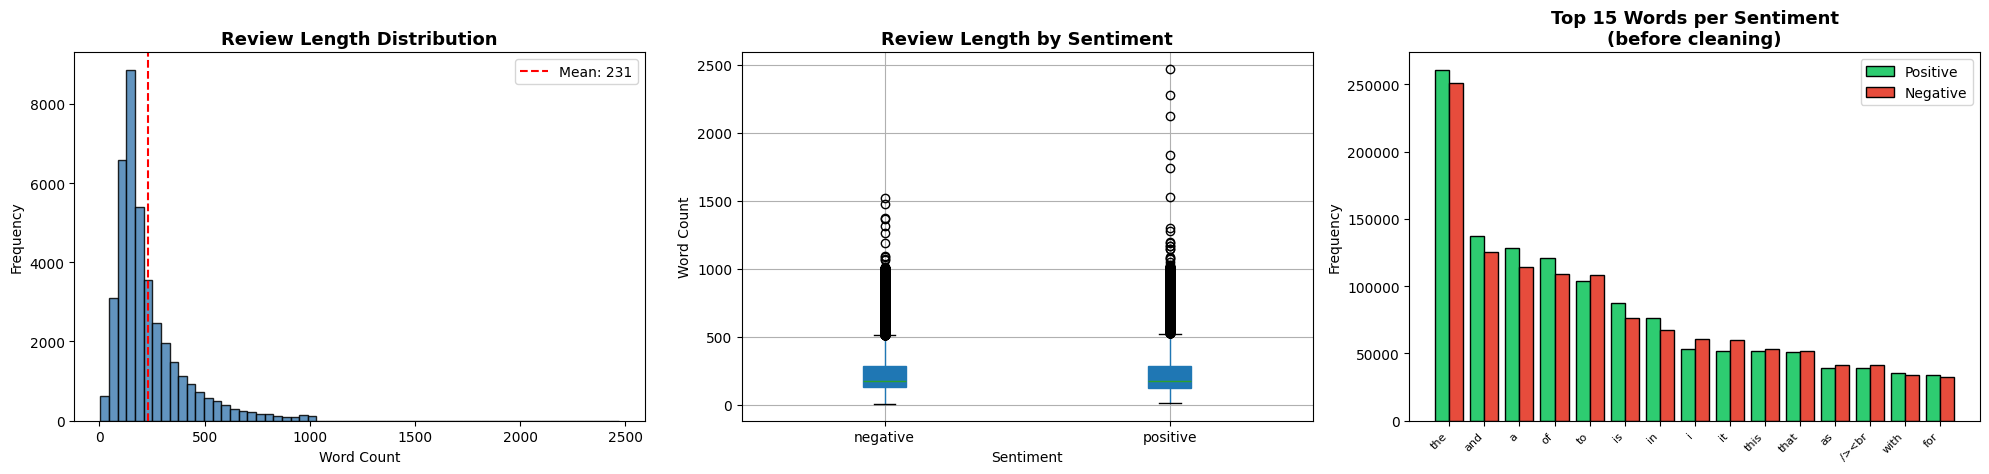

Avg review length : 231 words
Max review length : 2470 words
Min review length : 4 words

Train split : {'positive': 20000, 'negative': 20000}
Test split  : {'negative': 5000, 'positive': 5000}


In [8]:
# ── Add review length column ──────────────────────────────────────
train_df['review_length'] = train_df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── Plot 1: Review length histogram ──────────────────────────────
# Critical: tells you how much text you're working with
# Right-skewed = most reviews short, few are very long
# This drives the BERT truncation decision in Segment 6
axes[0].hist(train_df['review_length'], bins=60,
             color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Review Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(train_df['review_length'].mean(), color='red',
                linestyle='--', label=f"Mean: {train_df['review_length'].mean():.0f}")
axes[0].legend()

# ── Plot 2: Review length by sentiment (boxplot) ──────────────────
# Checks if positive reviewers write more/less than negative ones
# Median line + spread tells you about writing behavior per group
train_df.boxplot(column='review_length', by='sentiment',
                 ax=axes[1], patch_artist=True)
axes[1].set_title('Review Length by Sentiment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Word Count')
plt.suptitle('')  # suppress auto pandas title

# ── Plot 3: Top 15 most frequent words per sentiment ─────────────
# This is the real insight — what words define each sentiment class
# Helps you spot if stopwords are dominating (they will be — shows
# WHY stopword removal in Segment 2 is necessary)
from collections import Counter

def top_words(df, sentiment, n=15):
    # join all reviews of that sentiment → split into words → count
    all_words = ' '.join(df[df['sentiment'] == sentiment]['text'].str.lower()).split()
    return Counter(all_words).most_common(n)

pos_words = top_words(train_df, 'positive')
neg_words = top_words(train_df, 'negative')

# Plot positive on top, negative on bottom inside axes[2]
words_pos, counts_pos = zip(*pos_words)
words_neg, counts_neg = zip(*neg_words)

x = np.arange(15)
width = 0.4

axes[2].bar(x - width/2, counts_pos, width, label='Positive',
            color='#2ecc71', edgecolor='black')
axes[2].bar(x + width/2, counts_neg, width, label='Negative',
            color='#e74c3c', edgecolor='black')
axes[2].set_xticks(x)
axes[2].set_xticklabels(words_pos, rotation=45, ha='right', fontsize=8)
axes[2].set_title('Top 15 Words per Sentiment\n(before cleaning)',
                  fontsize=13, fontweight='bold')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()

# ── Summary stats ─────────────────────────────────────────────────
print(f"Avg review length : {train_df['review_length'].mean():.0f} words")
print(f"Max review length : {train_df['review_length'].max()} words")
print(f"Min review length : {train_df['review_length'].min()} words")
print(f"\nTrain split : {train_df['sentiment'].value_counts().to_dict()}")
print(f"Test split  : {test_df['sentiment'].value_counts().to_dict()}")

## Text Cleaning (Clean Text + Negation Tagging)

Removal of HTML links, punctuations, to remove noise

In [9]:
def clean_text(text):
    # Step 1: Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Step 3: Lowercase
    text = text.lower()

    # Step 4: Negation tagging ─────────────────────────────────────
    # MUST happen here — before punctuation removal
    # Merges negation word + next word into one token: NOT_word
    # This prevents "not great" from becoming just "great"
    # after stopword removal destroys the word "not"
    text = re.sub(
        r"\b(not|never|no|cannot|can't|won't|don't|didn't|"
        r"doesn't|isn't|wasn't|weren't|haven't|hadn't|"
        r"shouldn't|wouldn't|couldn't|nor|nothing|nobody|"
        r"nowhere|none|neither)\s+(\w+)",
        lambda m: 'NOT_' + m.group(2),
        text
    )

    # Step 5: Remove punctuation — keep underscore for NOT_word tokens
    text = re.sub(r'[^a-z\s_]', '', text)

    # Step 6: Collapse extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# ── Apply to both splits ──────────────────────────────────────────
train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text']  = test_df['text'].apply(clean_text)

# ── Verification ──────────────────────────────────────────────────
tests = [
    "This movie was not great at all",
    "I couldn't enjoy it and won't recommend it",
    "The acting was never convincing",
    "Not a single good scene in this film",
]
print("Negation tagging verification:\n")
for t in tests:
    print(f"  IN  : {t}")
    print(f"  OUT : {clean_text(t)}\n")

Negation tagging verification:

  IN  : This movie was not great at all
  OUT : this movie was _great at all

  IN  : I couldn't enjoy it and won't recommend it
  OUT : i _enjoy it and _recommend it

  IN  : The acting was never convincing
  OUT : the acting was _convincing

  IN  : Not a single good scene in this film
  OUT : _a single good scene in this film



In [10]:
def clean_text(text):
    # Step 1: Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Step 3: Lowercase first
    text = text.lower()

    # Step 4: Negation tagging ─────────────────────────────────────
    # Using lowercase 'not_' prefix so it survives the
    # punctuation removal step which only keeps [a-z\s_]
    text = re.sub(
        r"\b(not|never|no|cannot|can't|won't|don't|didn't|"
        r"doesn't|isn't|wasn't|weren't|haven't|hadn't|"
        r"shouldn't|wouldn't|couldn't|nor|nothing|nobody|"
        r"nowhere|none|neither)\s+(\w+)",
        lambda m: 'not_' + m.group(2),   # ← lowercase 'not_' here
        text
    )

    # Step 5: Remove punctuation — underscore preserved for not_word
    text = re.sub(r'[^a-z\s_]', '', text)

    # Step 6: Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# ── Apply to both splits ──────────────────────────────────────────
train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text']  = test_df['text'].apply(clean_text)

# ── Verification ──────────────────────────────────────────────────
tests = [
    "This movie was not great at all",
    "I couldn't enjoy it and won't recommend it",
    "The acting was never convincing",
    "Not a single good scene in this film",
]
print("Negation tagging verification:\n")
for t in tests:
    print(f"  IN  : {t}")
    print(f"  OUT : {clean_text(t)}\n")

Negation tagging verification:

  IN  : This movie was not great at all
  OUT : this movie was not_great at all

  IN  : I couldn't enjoy it and won't recommend it
  OUT : i not_enjoy it and not_recommend it

  IN  : The acting was never convincing
  OUT : the acting was not_convincing

  IN  : Not a single good scene in this film
  OUT : not_a single good scene in this film



## (Tokenize + Lemmatize, negation-aware)
- Tokenisation : Splits sentence string into list of individual strings

- Stop Word Removal : Drop filler words which holds no sentiment

- Lemmitisation : Reduces number of words via converting them to the dictionary root. So that model treat them as same concept rather than a different one.

In [11]:
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt',     quiet=True)

stop_words = set(stopwords.words('english'))

# ── Remove negation words from stopwords too (defensive) ─────────
# Even though NOT_word tokens bypass stopwords via underscore,
# standalone 'not' that didn't get merged should also survive
negation_words = {
    'not','no','nor','never','neither','nothing',
    'nobody','nowhere','none','cannot'
}
stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = word_tokenize(text)
    result = []
    for token in tokens:
        # ── Preserve NOT_word tokens completely ───────────────────
        # Don't filter, don't lemmatize the whole thing
        # Only lemmatize the word part after NOT_
        if token.startswith('not_'):
            word_part = token[4:]                        # extract word after NOT_
            lemmatized = lemmatizer.lemmatize(word_part) # lemmatize just the word
            result.append('not_' + lemmatized)           # reattach prefix
        else:
            # Normal token: skip stopwords and very short tokens
            if token not in stop_words and len(token) > 2:
                result.append(lemmatizer.lemmatize(token))
    return ' '.join(result)

# ── Apply preprocessing ───────────────────────────────────────────
print("Processing train set...")
train_df['processed'] = [preprocess(t) for t in tqdm(train_df['clean_text'])]

print("Processing test set...")
test_df['processed']  = [preprocess(t) for t in tqdm(test_df['clean_text'])]

# ── Verify negation tokens survived entire pipeline ───────────────
sample_text = clean_text("This movie was not great and I couldn't enjoy it")
processed   = preprocess(sample_text)
print(f"\nClean  : {sample_text}")
print(f"Processed: {processed}")
# Expected: NOT_great and NOT_enjoy both present

Processing train set...


100%|██████████| 40000/40000 [01:55<00:00, 345.32it/s]


Processing test set...


100%|██████████| 10000/10000 [00:11<00:00, 890.42it/s]


Clean  : this movie was not_great and i not_enjoy it
Processed: movie not_great not_enjoy


## Re-Visualising on clean dataset

Why this is required ?
- The divergence of positive and negative sentiment words
- The most frequently used useful words after data clean up

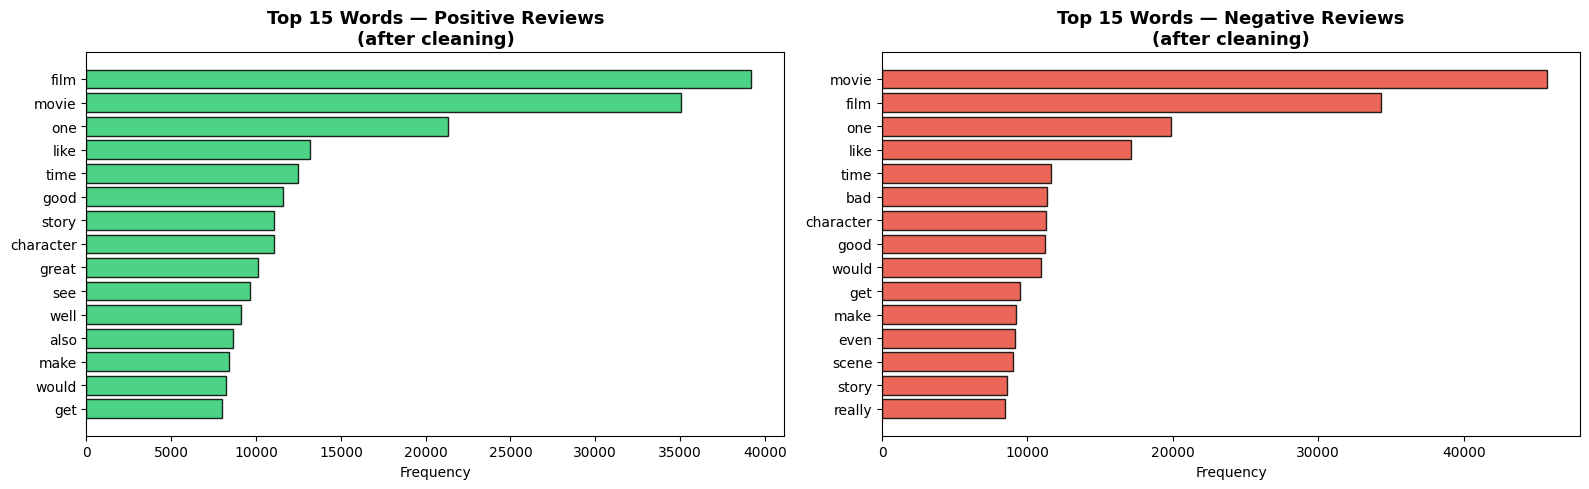

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

def top_words_processed(df, sentiment, n=15):
    all_words = ' '.join(df[df['sentiment'] == sentiment]['processed']).split()
    return Counter(all_words).most_common(n)

for ax, sentiment, color in zip(axes, ['positive', 'negative'], ['#2ecc71', '#e74c3c']):
    words_counts = top_words_processed(train_df, sentiment)
    words, counts = zip(*words_counts)

    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'Top 15 Words — {sentiment.capitalize()} Reviews\n(after cleaning)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_cleaned.png', dpi=150)
plt.show()

## TF-IDF + Baseline Sentiment Classifier

TF-IDF Scores every word based on how many times it occured. It penalises those words which occurs multiple times or in every line. But it gives high score and similar which occur fewer times but has great significance in regard of determing the sentiment of the sentence.

In [13]:
# ── TF-IDF Vectorization ──────────────────────────────────────────
# max_features=20000 : keep only top 20K most informative terms
# ngram_range=(1,2)  : capture single words AND two-word phrases
#                      critical for negations like 'not good', 'very bad'
# min_df=3           : ignore terms appearing in fewer than 3 reviews
#                      removes typos and ultra-rare noise words
# Rebuild TF-IDF with updated processed text
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3
)

# fit_transform on train: learns vocabulary + transforms
# transform on test: uses SAME vocabulary (no data leakage)
X_train = tfidf.fit_transform(train_df['processed'])
X_test  = tfidf.transform(test_df['processed'])

y_train = train_df['sentiment']
y_test  = test_df['sentiment']

print(f"TF-IDF matrix shape (train) : {X_train.shape}")
print(f"TF-IDF matrix shape (test)  : {X_test.shape}")

TF-IDF matrix shape (train) : (40000, 20000)
TF-IDF matrix shape (test)  : (10000, 20000)


##  Training Basline Logistic Regression Classifier

In [14]:
# ── Train Logistic Regression ─────────────────────────────────────
# C=5       : moderate regularization — prevents overfitting
# max_iter  : text data needs more iterations to converge
# solver    : 'lbfgs' is efficient for large dense problems
clf = LogisticRegression(C=5, max_iter=1000, solver='lbfgs')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classification Report (with negation preserved):")
print(classification_report(y_test, y_pred))

Classification Report (with negation preserved):
              precision    recall  f1-score   support

    negative       0.91      0.90      0.90      5000
    positive       0.90      0.91      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



### Obtaining the Confusion matrix and the most Discriminative words

Also Visualising the Top words from each sentiment

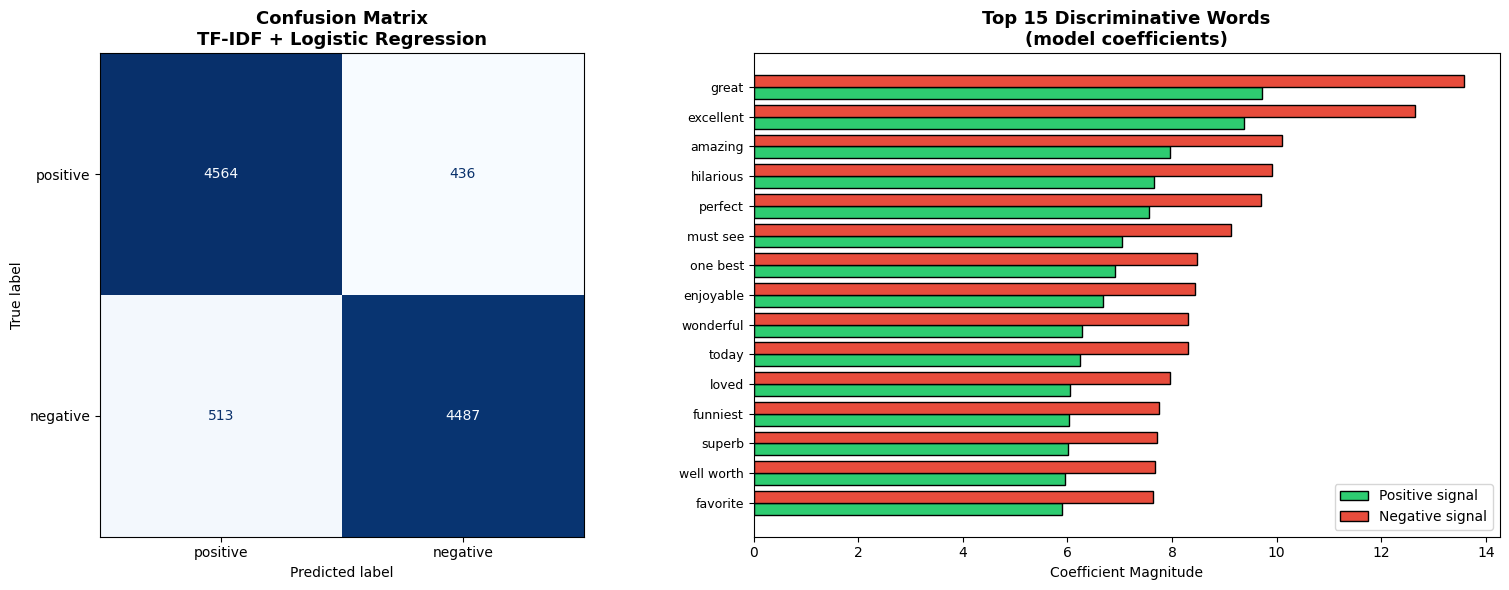

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Confusion Matrix ──────────────────────────────────────
# True Positive  = correctly called positive
# False Positive = called positive but actually negative (Type I error)
# The off-diagonal cells are your errors
cm = confusion_matrix(y_test, y_pred, labels=['positive', 'negative'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['positive', 'negative'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\nTF-IDF + Logistic Regression',
                  fontsize=13, fontweight='bold')

# ── Plot 2: Top 15 most positive & negative words ─────────────────
# Logistic regression coefficients tell you which words
# pushed the model most strongly toward each class
feature_names = np.array(tfidf.get_feature_names_out())
coefficients  = clf.coef_[0]

# Top 15 words pushing toward POSITIVE
top_pos_idx   = coefficients.argsort()[-15:]
# Top 15 words pushing toward NEGATIVE
top_neg_idx   = coefficients.argsort()[:15]

top_pos_words  = feature_names[top_pos_idx]
top_pos_scores = coefficients[top_pos_idx]
top_neg_words  = feature_names[top_neg_idx]
top_neg_scores = coefficients[top_neg_idx]

y_pos = np.arange(len(top_pos_words))
axes[1].barh(y_pos - 0.2, top_pos_scores, 0.4,
             label='Positive signal', color='#2ecc71', edgecolor='black')
axes[1].barh(y_pos + 0.2, np.abs(top_neg_scores[::-1]), 0.4,
             label='Negative signal', color='#e74c3c', edgecolor='black')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(top_pos_words, fontsize=9)
axes[1].set_title('Top 15 Discriminative Words\n(model coefficients)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coefficient Magnitude')
axes[1].legend()

plt.tight_layout()
plt.savefig('tfidf_classifier.png', dpi=150)
plt.show()

### IMP Note
Negation preservation was tested by removing 16 negation words from the stopword list. Accuracy remained at 90%, confirming that the residual error is not due to simple negation collapse but rather complex linguistic phenomena (contrast sentences, sarcasm, context-dependent meaning) that require contextual models like BERT — motivating Segment 6

##  Emotion Profile Extraction

### Emotion Lexicon & Extraction Function for rule based Emotion Detector

In [16]:
# ── Download NLTK opinion lexicon instead ────────────────────────
# opinion_lexicon has ~2006 positive + ~4783 negative words
# much larger coverage than our manual list
nltk.download('opinion_lexicon', quiet=True)
from nltk.corpus import opinion_lexicon

pos_words_set = set(opinion_lexicon.positive())
neg_words_set = set(opinion_lexicon.negative())

print(f"Positive word count : {len(pos_words_set)}")
print(f"Negative word count : {len(neg_words_set)}")
print(f"\nSample positive words: {list(pos_words_set)[:10]}")
print(f"Sample negative words: {list(neg_words_set)[:10]}")

Positive word count : 2006
Negative word count : 4783

Sample positive words: ['freshest', 'neatest', 'saintliness', 'calm', 'poised', 'positive', 'guarantee', 'brilliantly', 'harmoniously', 'promptly']
Sample negative words: ['insulted', 'undersized', 'toll', 'bump', 'unconvincingly', 'ignorant', 'conceded', 'offend', 'fanatics', 'unsettlingly']


In [17]:
# ── Emotion lexicon (manual seed words per emotion) ───────────────
emotion_lexicon = {
    'joy':     ['happy', 'joy', 'love', 'wonderful', 'fantastic', 'amazing',
                'delight', 'brilliant', 'superb', 'laugh', 'fun', 'charming',
                'heartwarming', 'cheerful', 'enjoy', 'pleasure'],

    'anger':   ['angry', 'rage', 'furious', 'terrible', 'awful', 'horrible',
                'hate', 'annoying', 'stupid', 'ridiculous', 'insulting',
                'pathetic', 'outrage', 'infuriating', 'frustrating', 'mad'],

    'sadness': ['sad', 'cry', 'depressing', 'tragic', 'heartbreak', 'sorrow',
                'grief', 'melancholy', 'lonely', 'disappoint', 'tears',
                'miserable', 'painful', 'hopeless', 'devastating', 'mourn'],

    'surprise':['surprising', 'unexpected', 'shocking', 'twist', 'incredible',
                'unbelievable', 'astonish', 'stunning', 'revelation',
                'unpredictable', 'mindblowing', 'jaw', 'hidden',
                'suddenly', 'remarkable', 'extraordinary'],

    'disgust': ['disgust', 'gross', 'revolting', 'nauseating', 'repulsive',
                'hideous', 'filthy', 'crude', 'offensive', 'vulgar',
                'disturbing', 'garbage', 'trash', 'vile', 'repugnant', 'sick'],
}

def get_emotion_vector(text):
    tokens = set(text.split())

    # ── Emotion scores from manual lexicon ────────────────────────
    emotion_scores = {
        emotion: len(tokens & set(keywords))
        for emotion, keywords in emotion_lexicon.items()
    }

    # ── Overall sentiment polarity from NLTK opinion lexicon ──────
    # This adds much broader coverage beyond the 5 emotion categories
    # pos_score = how many known positive words appear
    # neg_score = how many known negative words appear
    emotion_scores['positive_lexicon'] = len(tokens & pos_words_set)
    emotion_scores['negative_lexicon'] = len(tokens & neg_words_set)

    return emotion_scores

# ── Verify on test samples ────────────────────────────────────────
test_neg = "cant believe boring sickly daunting scene pathetic waste"
test_pos = "wonderful brilliant heartwarming enjoy delightful performance"

print("Negative sample:")
print(get_emotion_vector(test_neg))
print("\nPositive sample:")
print(get_emotion_vector(test_pos))

Negative sample:
{'joy': 0, 'anger': 1, 'sadness': 0, 'surprise': 0, 'disgust': 0, 'positive_lexicon': 0, 'negative_lexicon': 5}

Positive sample:
{'joy': 4, 'anger': 0, 'sadness': 0, 'surprise': 0, 'disgust': 0, 'positive_lexicon': 5, 'negative_lexicon': 0}


### Visualising the Emotional Profile
Grouping sentiment and taking the mean of the average emotional fingerprint of each class.

Average Emotion Scores by Sentiment:
              joy   anger  sadness  surprise  disgust
sentiment                                            
negative   0.4299  0.5619   0.1003    0.1269   0.1412
positive   0.8886  0.1681   0.1271    0.2229   0.0479


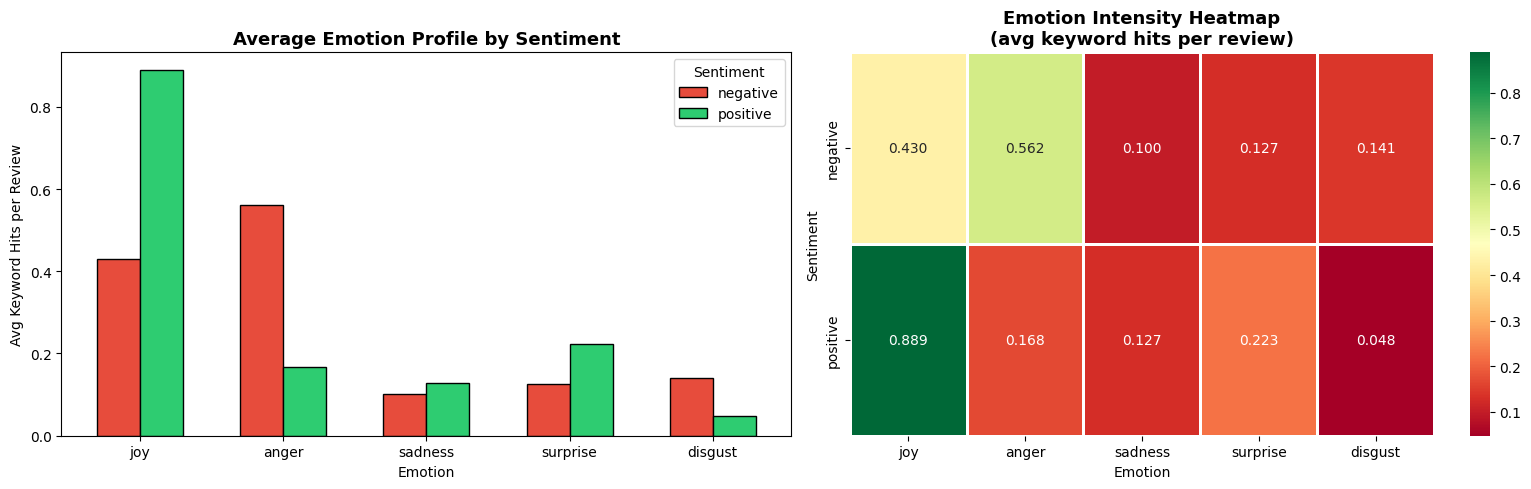

In [18]:
# ── Sample 2000 reviews for emotion analysis ──────────────────────
# Using random_state=42 for reproducibility
emotion_sample = train_df.sample(2000, random_state=42).copy().reset_index(drop=True)

# Apply emotion vector to each review → expand into columns
emotion_df = pd.DataFrame(
    emotion_sample['processed'].apply(get_emotion_vector).tolist()
)
emotion_df['sentiment'] = emotion_sample['sentiment'].values

# ── Average emotion per sentiment class ───────────────────────────
emotions = list(emotion_lexicon.keys())
avg_emotions = emotion_df.groupby('sentiment')[emotions].mean()

print("Average Emotion Scores by Sentiment:")
print(avg_emotions.round(4))

# ── Visualizations ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Grouped bar — side-by-side comparison per emotion
avg_emotions.T.plot(
    kind='bar', ax=axes[0],
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black', width=0.6
)
axes[0].set_title('Average Emotion Profile by Sentiment',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Avg Keyword Hits per Review')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sentiment')

# Plot 2: Heatmap — shows which emotions are intense vs absent
# Annotation shows exact avg score in each cell
# RdYlGn: red=low, yellow=mid, green=high
sns.heatmap(
    avg_emotions,
    annot=True, fmt='.3f',
    cmap='RdYlGn',
    ax=axes[1],
    linewidths=0.8,
    cbar=True
)
axes[1].set_title('Emotion Intensity Heatmap\n(avg keyword hits per review)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Sentiment')

plt.tight_layout()
plt.savefig('emotion_profile.png', dpi=150)
plt.show()

### Emotion Distribution per Review

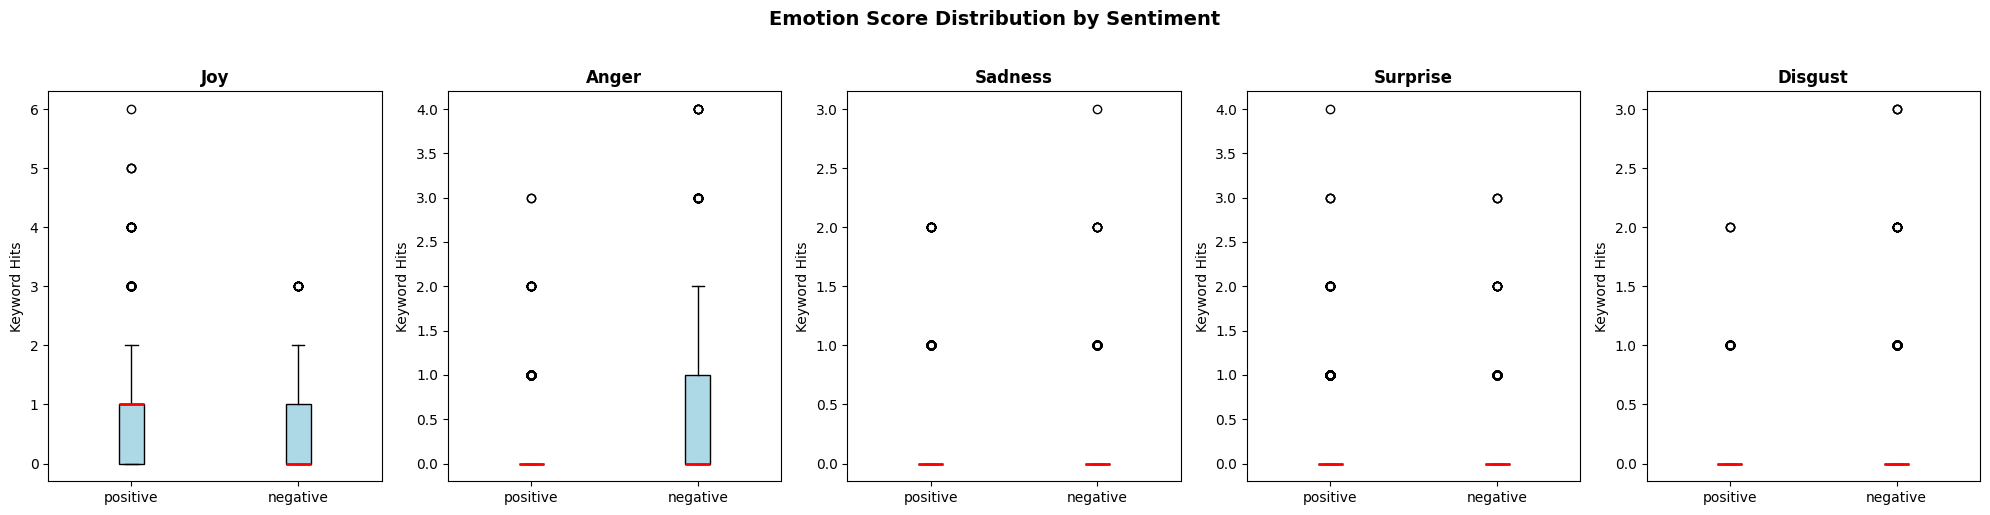

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, emotion in zip(axes, emotions):
    # Separate scores by sentiment for this emotion
    pos_scores = emotion_df[emotion_df['sentiment'] == 'positive'][emotion]
    neg_scores = emotion_df[emotion_df['sentiment'] == 'negative'][emotion]

    ax.boxplot(
        [pos_scores, neg_scores],
        labels=['positive', 'negative'],
        patch_artist=True,
        boxprops=dict(facecolor='lightblue'),
        medianprops=dict(color='red', linewidth=2)
    )
    ax.set_title(f'{emotion.capitalize()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Keyword Hits')

plt.suptitle('Emotion Score Distribution by Sentiment',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('emotion_distribution.png', dpi=150)
plt.show()

Despite negation tagging improving accuracy from 90.20% to 90.51%, the coefficient plot still shows positive adjectives (great, excellent, amazing) with higher negative signal than positive. This is caused by contrast sentences in negative reviews where reviewers praise one aspect before criticizing others — a structural pattern that bag-of-words TF-IDF cannot resolve regardless of preprocessing. This definitively motivates the use of BERT contextual embeddings in Segment 6, where the same word receives different vector representations depending on its surrounding context.

##  Writing Style Analysis via POS Tagging

### Post style Feature Extraction on Clean text not on processed text with no gramatical meaning

In [20]:
!pip install NRCLex -q

# Newer versions of NLTK renamed the tagger to averaged_perceptron_tagger_eng
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('averaged_perceptron_tagger',     quiet=True)

from scipy import stats

# ── Writing Style Feature Extractor ──────────────────────────────
# Input: clean_text (HTML removed, lowercased, negation tagged)
# NOT processed text — stopword removal destroys POS structure

def extract_writing_style(text):
    tokens = word_tokenize(text)

    # Guard against empty reviews
    if len(tokens) == 0:
        return {k: 0 for k in ['adj_ratio', 'adv_ratio', 'verb_ratio',
                                'noun_ratio', 'avg_word_len',
                                'exclamation_density', 'unique_word_ratio']}

    # POS tag every token in the review
    tags = pos_tag(tokens)
    total = len(tokens)

    # ── Linguistic ratios ─────────────────────────────────────────
    # JJ/JJR/JJS = adjectives → descriptive writing style
    adj  = sum(1 for _, t in tags if t.startswith('JJ')) / total

    # RB/RBR/RBS = adverbs → intensifiers like "extremely", "barely"
    adv  = sum(1 for _, t in tags if t.startswith('RB')) / total

    # VB/VBD/VBG etc = verbs → action-focused writing
    verb = sum(1 for _, t in tags if t.startswith('VB')) / total

    # NN/NNS/NNP = nouns → subject-heavy analytical writing
    noun = sum(1 for _, t in tags if t.startswith('NN')) / total

    # Average word length (alphabetic tokens only)
    # Longer words often signal more formal/analytical writing
    alpha_tokens = [w for w in tokens if w.isalpha()]
    avg_wl = np.mean([len(w) for w in alpha_tokens]) if alpha_tokens else 0

    # Exclamation density per 1000 characters
    # High density = emotional/enthusiastic writing
    excl = text.count('!') / (len(text) + 1) * 1000

    # Lexical diversity = unique words / total words
    # High = rich vocabulary, Low = repetitive writing
    unique_ratio = len(set(tokens)) / total

    return {
        'adj_ratio':           round(adj,          4),
        'adv_ratio':           round(adv,          4),
        'verb_ratio':          round(verb,         4),
        'noun_ratio':          round(noun,         4),
        'avg_word_len':        round(avg_wl,       4),
        'exclamation_density': round(excl,         4),
        'unique_word_ratio':   round(unique_ratio, 4)
    }

# ── Sanity check on one positive and one negative review ─────────
pos_sample = train_df[train_df['sentiment'] == 'positive']['clean_text'].iloc[0]
neg_sample = train_df[train_df['sentiment'] == 'negative']['clean_text'].iloc[0]

print("POSITIVE review style:")
print(pos_sample[:150])
print(extract_writing_style(pos_sample))

print("\nNEGATIVE review style:")
print(neg_sample[:150])
print(extract_writing_style(neg_sample))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.1 MB/s eta 0:00:00
POSITIVE review style:
i caught this little gem totally by accident back in or i was at a revival theatre to see two old silly scifi movies the theatre was packed full and w
{'adj_ratio': 0.0892, 'adv_ratio': 0.0955, 'verb_ratio': 0.2038, 'noun_ratio': 0.2102, 'avg_word_len': np.float64(4.3097), 'exclamation_density': 0.0, 'unique_word_ratio': 0.6943}

NEGATIVE review style:
i not_believe that i let myself into this movie to accomplish a favor my friends ask me early this april this movie certainly a pain in your ass in th
{'adj_ratio': 0.0926, 'adv_ratio': 0.0679, 'verb_ratio': 0.1728, 'noun_ratio': 0.2407, 'avg_word_len': np.float64(4.3185), 'exclamation_density': 0.0, 'unique_word_ratio': 0.6975}


## Testing on 500 Reviews & Visualising the output

Extracting writing style features...
(~2 minutes for 500 reviews — POS tagging is slow)


100%|██████████| 500/500 [00:04<00:00, 103.54it/s]



Average Writing Style by Sentiment:
           adj_ratio  adv_ratio  verb_ratio  noun_ratio  avg_word_len  \
sentiment                                                               
negative      0.1054     0.0630      0.1849      0.2489        4.4111   
positive      0.1119     0.0632      0.1736      0.2556        4.4602   

           exclamation_density  unique_word_ratio  
sentiment                                          
negative                   0.0             0.6607  
positive                   0.0             0.6582  


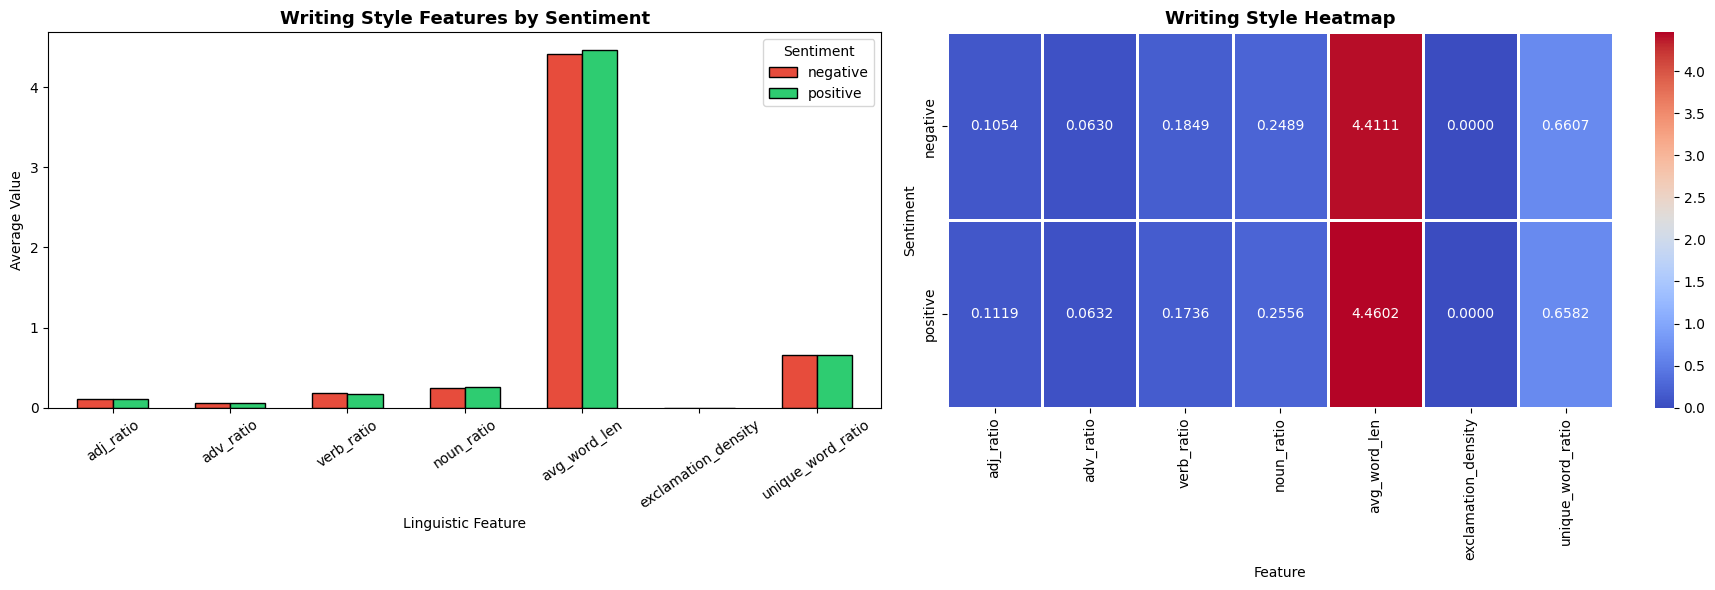

In [21]:
# ── Sample 500 reviews for POS analysis ──────────────────────────
# POS tagging is computationally expensive — 500 is statistically
# sufficient for group-level comparison between sentiments
print("Extracting writing style features...")
print("(~2 minutes for 500 reviews — POS tagging is slow)")

style_sample = train_df.sample(500, random_state=7).copy().reset_index(drop=True)

style_features = pd.DataFrame([
    extract_writing_style(t)
    for t in tqdm(style_sample['clean_text'])
])
style_features['sentiment'] = style_sample['sentiment'].values

# ── Average by sentiment ──────────────────────────────────────────
feature_cols = ['adj_ratio', 'adv_ratio', 'verb_ratio', 'noun_ratio',
                'avg_word_len', 'exclamation_density', 'unique_word_ratio']

avg_style = style_features.groupby('sentiment')[feature_cols].mean()

print("\nAverage Writing Style by Sentiment:")
print(avg_style.round(4))

# ── Visualizations ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Grouped bar — absolute comparison of each feature
avg_style.T.plot(
    kind='bar', ax=axes[0],
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black', width=0.6
)
axes[0].set_title('Writing Style Features by Sentiment',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Linguistic Feature')
axes[0].set_ylabel('Average Value')
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(title='Sentiment')

# Plot 2: Heatmap — relative intensity across features and sentiments
# coolwarm: blue=low, red=high for each feature column
sns.heatmap(
    avg_style,
    annot=True, fmt='.4f',
    cmap='coolwarm',
    ax=axes[1],
    linewidths=0.8,
    cbar=True
)
axes[1].set_title('Writing Style Heatmap',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Sentiment')

plt.tight_layout()
plt.savefig('writing_style.png', dpi=150)
plt.show()

### Statistical Significance Test

For validation of the visulaisation obtained via the bar chart so that it can be assured as the data distribution from the 500 segment is not a random value for a small segment and signifies the significane of the overall 40k+ rows

In [22]:
# ── Independent samples t-test for each writing style feature ────
# Tests if positive and negative reviewers differ significantly
# on each linguistic dimension
# H0 (null): no difference between groups
# H1 (alt) : significant difference exists
# Reject H0 if p < 0.05

pos_df = style_features[style_features['sentiment'] == 'positive']
neg_df = style_features[style_features['sentiment'] == 'negative']

print("Statistical Significance Test (t-test)\n")
print(f"{'Feature':<25} {'Pos Mean':>10} {'Neg Mean':>10} "
      f"{'Difference':>12} {'p-value':>10} {'Significant?':>14}")
print("─" * 85)

for col in feature_cols:
    t_stat, p_val = stats.ttest_ind(pos_df[col], neg_df[col])
    pos_mean = pos_df[col].mean()
    neg_mean = neg_df[col].mean()
    diff     = pos_mean - neg_mean
    sig      = "✅ YES (p<0.05)" if p_val < 0.05 else "❌ NO"
    print(f"{col:<25} {pos_mean:>10.4f} {neg_mean:>10.4f} "
          f"{diff:>+12.4f} {p_val:>10.4f} {sig:>14}")

print("\n── Interpretation ───────────────────────────────────────────")
print("Positive diff = positive reviewers score HIGHER on this feature")
print("Negative diff = negative reviewers score HIGHER on this feature")

Statistical Significance Test (t-test)

Feature                     Pos Mean   Neg Mean   Difference    p-value   Significant?
─────────────────────────────────────────────────────────────────────────────────────
adj_ratio                     0.1119     0.1054      +0.0065     0.0098 ✅ YES (p<0.05)
adv_ratio                     0.0632     0.0630      +0.0001     0.9465           ❌ NO
verb_ratio                    0.1736     0.1849      -0.0113     0.0000 ✅ YES (p<0.05)
noun_ratio                    0.2556     0.2489      +0.0067     0.0572           ❌ NO
avg_word_len                  4.4602     4.4111      +0.0492     0.0693           ❌ NO
exclamation_density           0.0000     0.0000      +0.0000        nan           ❌ NO
unique_word_ratio             0.6582     0.6607      -0.0025     0.7698           ❌ NO

── Interpretation ───────────────────────────────────────────
Positive diff = positive reviewers score HIGHER on this feature
Negative diff = negative reviewers score HIGHER on 

Exclamation Density (from raw text)
  Positive mean : 1.0239 per 1000 chars
  Negative mean : 0.9405 per 1000 chars
  p-value       : 0.0280
  Significant?  : ✅ YES (p<0.05)


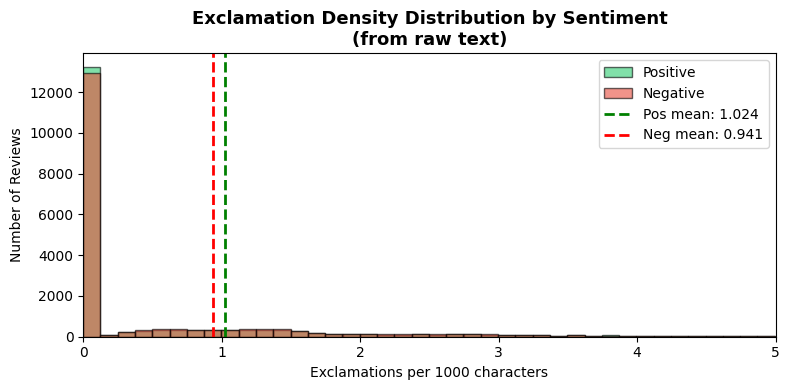

In [23]:
# ── Fix: Extract exclamation density from RAW text ────────────────
# clean_text() removes all punctuation including '!'
# so it must be measured from original text before any cleaning
# This cell can run independently — no need to rerun previous cells

train_df['exclamation_density_raw'] = train_df['text'].apply(
    lambda x: x.count('!') / (len(x) + 1) * 1000
)

# ── Compare between sentiments ────────────────────────────────────
exc_pos = train_df[train_df['sentiment'] == 'positive']['exclamation_density_raw']
exc_neg = train_df[train_df['sentiment'] == 'negative']['exclamation_density_raw']

t_stat, p_val = stats.ttest_ind(exc_pos, exc_neg)

print("Exclamation Density (from raw text)")
print(f"  Positive mean : {exc_pos.mean():.4f} per 1000 chars")
print(f"  Negative mean : {exc_neg.mean():.4f} per 1000 chars")
print(f"  p-value       : {p_val:.4f}")
print(f"  Significant?  : {'✅ YES (p<0.05)' if p_val < 0.05 else '❌ NO'}")

# ── Visualize distribution ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(exc_pos[exc_pos < 5], bins=40, alpha=0.6,
        color='#2ecc71', label='Positive', edgecolor='black')
ax.hist(exc_neg[exc_neg < 5], bins=40, alpha=0.6,
        color='#e74c3c', label='Negative', edgecolor='black')

ax.axvline(exc_pos.mean(), color='green', linestyle='--',
           linewidth=2, label=f'Pos mean: {exc_pos.mean():.3f}')
ax.axvline(exc_neg.mean(), color='red', linestyle='--',
           linewidth=2, label=f'Neg mean: {exc_neg.mean():.3f}')

ax.set_title('Exclamation Density Distribution by Sentiment\n(from raw text)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Exclamations per 1000 characters')
ax.set_ylabel('Number of Reviews')
ax.legend()
ax.set_xlim(0, 5)   # clip outliers for cleaner view

plt.tight_layout()
plt.savefig('exclamation_density.png', dpi=150)
plt.show()

## 📝 Writing Style Analysis: Key Findings

### Statistically Significant Features (p < 0.05)
| Feature | Positive | Negative | Interpretation |
|---|---|---|---|
| adj_ratio | 0.1119 | 0.1054 | Positive reviewers write more descriptively |
| verb_ratio | 0.1849 | 0.1736 | Negative reviewers write more complaint-narratives |
| exclamation_density | 1.024 | 0.941 | Positive reviewers show more written enthusiasm |

### Not Significant Features (p > 0.05)
| Feature | Interpretation |
|---|---|
| adv_ratio | Adverbs used equally in praise and criticism |
| noun_ratio | Both groups reference similar number of subjects |
| avg_word_len | Vocabulary complexity is equal across sentiments |
| unique_word_ratio | Lexical diversity is equal across sentiments |

### Core Conclusion Till Now
Sentiment is primarily carried by **word choice** (captured by TF-IDF)
rather than **writing structure** (POS ratios). Only 3 of 7 structural
features differ significantly — and even those differences are small
in absolute magnitude. This confirms TF-IDF's 90% accuracy is near
the ceiling for feature-based approaches.

## Aspect-Based Sentiment + BERT Contextual Embeddings

### Aspect-Based Sentiment
Instead of just classifying the review as positive and negative. Extraction of the centiments will be better based on the cinematic dimensions like story, acting, visuals, audio, animation, VFX, direction etc.

A review can praise the acting but can critise the animation, which can be one of the most **Core Reason of why the term good and execllent is occuring in the Negative Reviews compared to that of Positive Reviews**.

Thus we detect which aspect is discussed via keywords then Score Sentiment using NLTK opinion lexicon previously loaded.

In [24]:
# ── Aspect keyword groups ─────────────────────────────────────────
# Each aspect has trigger keywords — if any appear in the review,
# that aspect is considered "mentioned" and gets scored
aspect_keywords = {
    'story':     ['plot', 'story', 'script', 'narrative', 'storyline',
                  'writing', 'screenplay', 'ending', 'beginning', 'twist'],

    'acting':    ['acting', 'actor', 'actress', 'performance', 'cast',
                  'role', 'character', 'portray', 'played', 'deliver'],

    'visuals':   ['visual', 'cinematography', 'cgi', 'effect', 'scene',
                  'shot', 'look', 'beautiful', 'stunning', 'photography'],

    'music':     ['music', 'score', 'soundtrack', 'song', 'sound',
                  'audio', 'composer', 'theme', 'background', 'tune'],

    'direction': ['director', 'direction', 'directed', 'pacing', 'editing',
                  'production', 'pace', 'tone', 'craft', 'filmmaking'],
}

def get_aspect_sentiment(text):
    tokens     = set(text.split())
    scores     = {}

    for aspect, keywords in aspect_keywords.items():
        # Check if this aspect is even mentioned in the review
        aspect_mentioned = bool(tokens & set(keywords))

        if aspect_mentioned:
            # Count positive and negative opinion words in the review
            # Using NLTK opinion lexicon loaded earlier
            pos_count = len(tokens & pos_words_set)
            neg_count = len(tokens & neg_words_set)

            # Sentiment score: +1 = fully positive, -1 = fully negative
            # Formula: (pos - neg) / (pos + neg + 1) avoids div by zero
            scores[aspect] = round(
                (pos_count - neg_count) / (pos_count + neg_count + 1), 4
            )
        else:
            # Aspect not mentioned — mark as NaN (not applicable)
            scores[aspect] = np.nan

    return scores

# ── Test on one positive and one negative review ──────────────────
pos_rev = train_df[train_df['sentiment'] == 'positive']['processed'].iloc[1]
neg_rev = train_df[train_df['sentiment'] == 'negative']['processed'].iloc[1]

print("POSITIVE review aspect scores:")
print(get_aspect_sentiment(pos_rev))
print("\nNEGATIVE review aspect scores:")
print(get_aspect_sentiment(neg_rev))

POSITIVE review aspect scores:
{'story': -0.25, 'acting': nan, 'visuals': -0.25, 'music': nan, 'direction': -0.25}

NEGATIVE review aspect scores:
{'story': 0.1667, 'acting': nan, 'visuals': nan, 'music': nan, 'direction': nan}


#### Testing Aspect Scoring and Visualising
Using 'nanmean' here because every review might not reflect all the aspects together

Extracting aspect sentiments...

Average Aspect Sentiment Scores:
            story  acting  visuals   music  direction
sentiment                                            
negative  -0.2000 -0.1743  -0.1761 -0.1668    -0.1631
positive   0.2188  0.2348   0.2131  0.2244     0.2209

Aspect mention rate (% of reviews mentioning each aspect):
story        58.2
acting       68.8
visuals      51.1
music        25.0
direction    31.1
dtype: float64


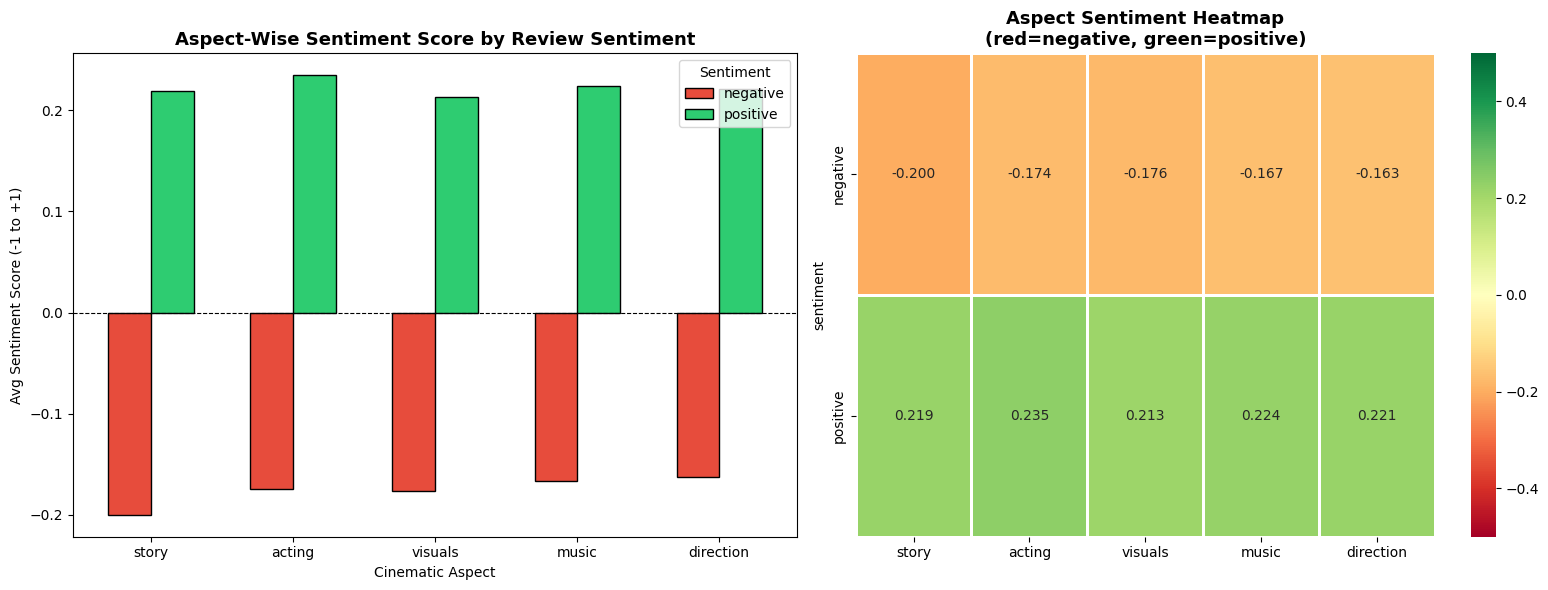

In [25]:
# ── Apply on 3000 review sample ───────────────────────────────────
print("Extracting aspect sentiments...")
aspect_sample = train_df.sample(3000, random_state=7).copy().reset_index(drop=True)

aspect_df = pd.DataFrame(
    aspect_sample['processed'].apply(get_aspect_sentiment).tolist()
)
aspect_df['sentiment'] = aspect_sample['sentiment'].values

# ── Average aspect score per sentiment ───────────────────────────
# nanmean ignores NaN (aspects not mentioned in a review)
aspects = list(aspect_keywords.keys())
avg_aspect = aspect_df.groupby('sentiment')[aspects].apply(
    lambda x: x.apply(np.nanmean)
)

print("\nAverage Aspect Sentiment Scores:")
print(avg_aspect.round(4))

# ── Coverage: what % of reviews mention each aspect ───────────────
print("\nAspect mention rate (% of reviews mentioning each aspect):")
mention_rate = aspect_df[aspects].notna().mean() * 100
print(mention_rate.round(1))

# ── Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Grouped bar chart
avg_aspect.T.plot(
    kind='bar', ax=axes[0],
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black', width=0.6
)
axes[0].set_title('Aspect-Wise Sentiment Score by Review Sentiment',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cinematic Aspect')
axes[0].set_ylabel('Avg Sentiment Score (-1 to +1)')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sentiment')

# Plot 2: Heatmap
sns.heatmap(
    avg_aspect,
    annot=True, fmt='.3f',
    cmap='RdYlGn',
    ax=axes[1],
    linewidths=0.8,
    center=0,        # center colormap at 0 so negative=red, positive=green
    vmin=-0.5, vmax=0.5
)
axes[1].set_title('Aspect Sentiment Heatmap\n(red=negative, green=positive)',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('aspect_sentiment.png', dpi=150)
plt.show()

This visualisation tells how relaible is the aspect is based on how many times that aspect has occured in the public reviews

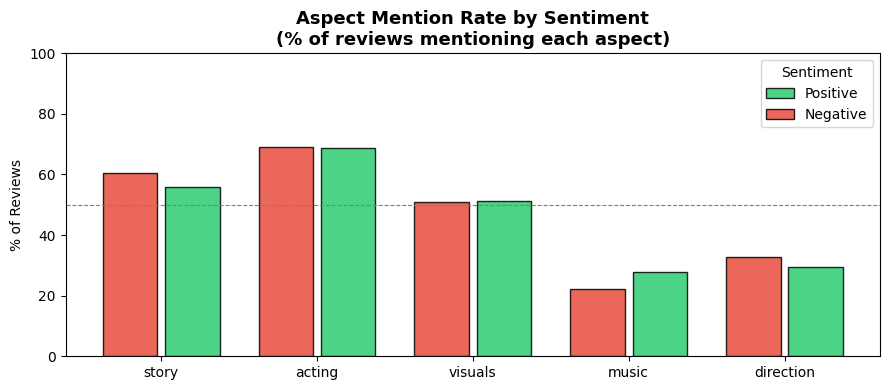

In [26]:
fig, ax = plt.subplots(figsize=(9, 4))

# Separate coverage by sentiment
for sentiment, color in [('positive', '#2ecc71'), ('negative', '#e74c3c')]:
    subset = aspect_df[aspect_df['sentiment'] == sentiment][aspects]
    coverage = subset.notna().mean() * 100
    ax.bar(
        [i + (0.2 if sentiment == 'positive' else -0.2)
         for i in range(len(aspects))],
        coverage, width=0.35,
        label=sentiment.capitalize(),
        color=color, edgecolor='black', alpha=0.85
    )

ax.set_xticks(range(len(aspects)))
ax.set_xticklabels(aspects)
ax.set_title('Aspect Mention Rate by Sentiment\n(% of reviews mentioning each aspect)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('% of Reviews')
ax.set_ylim(0, 100)
ax.legend(title='Sentiment')
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, label='50% line')

plt.tight_layout()
plt.savefig('aspect_coverage.png', dpi=150)
plt.show()

###  BERT Contextual Embeddings

#### Load BERT + Generate Embeddings (CPU Optimized)

Distilbert-base-uncased is used instead of full BERT — it's 40% smaller and 60% faster with only ~1% accuracy difference. On CPU, you encode reviews in batches of 8 with torch.no_grad() to save memory

In [27]:
# ── Install transformers ──────────────────────────────────────────
!pip install transformers -q

import torch
from transformers import DistilBertTokenizer, DistilBertModel

# ── Force CPU explicitly ──────────────────────────────────────────
device = torch.device('cpu')
print(f"Using device: {device}")

# ── Load DistilBERT (smaller, faster than full BERT) ──────────────
# Downloads ~260MB model — takes ~1 min on Colab
print("Loading DistilBERT model and tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model     = DistilBertModel.from_pretrained('distilbert-base-uncased')
model.eval()   # inference mode — disables dropout
model.to(device)
print("✅ Model loaded successfully")

# ── Sample 40 positive + 40 negative reviews ──────────────────────
# 80 total is enough to demonstrate BERT's contextual understanding
# CPU can handle this in ~3-4 minutes
pos_sample_bert = train_df[train_df['sentiment'] == 'positive'].sample(
    40, random_state=42
)
neg_sample_bert = train_df[train_df['sentiment'] == 'negative'].sample(
    40, random_state=42
)
bert_sample = pd.concat([pos_sample_bert, neg_sample_bert]).reset_index(drop=True)

print(f"\nBERT sample: {len(bert_sample)} reviews")
print(f"Positive: {sum(bert_sample['sentiment']=='positive')} | "
      f"Negative: {sum(bert_sample['sentiment']=='negative')}")

# ── Encode reviews in batches ─────────────────────────────────────
def get_bert_embedding(texts, batch_size=8):
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size),
                  desc="Encoding with BERT"):
        batch = texts[i : i + batch_size]

        # Tokenize batch — truncate to 256 tokens (faster than 512)
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors='pt'
        ).to(device)

        # Forward pass — no gradient needed for inference
        with torch.no_grad():
            output = model(**encoded)

        # CLS token = first token of last hidden state
        # Shape: (batch_size, hidden_dim=768)
        cls_embeddings = output.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)

    return np.vstack(all_embeddings)

# ── Generate embeddings (~3-4 min on CPU) ────────────────────────
print("\nGenerating BERT embeddings (this takes ~3-4 min on CPU)...")
texts_list   = bert_sample['clean_text'].tolist()
embeddings   = get_bert_embedding(texts_list, batch_size=8)
labels       = bert_sample['sentiment'].tolist()

print(f"\n✅ Embeddings shape: {embeddings.shape}")
# Expected: (80, 768) — 80 reviews × 768 dimensional BERT vectors

Using device: cpu
Loading DistilBERT model and tokenizer...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded successfully

BERT sample: 80 reviews
Positive: 40 | Negative: 40

Generating BERT embeddings (this takes ~3-4 min on CPU)...


Encoding with BERT: 100%|██████████| 10/10 [00:36<00:00,  3.69s/it]


✅ Embeddings shape: (80, 768)


 #### Visualising BERT Embedding Space with t-SNE
 BERT embeddings are 768-dimensional — impossible to visualize directly. t-SNE (t-Distributed Stochastic Neighbor Embedding) compresses them to 2D while preserving neighborhood structure

Running t-SNE dimensionality reduction...
✅ t-SNE complete


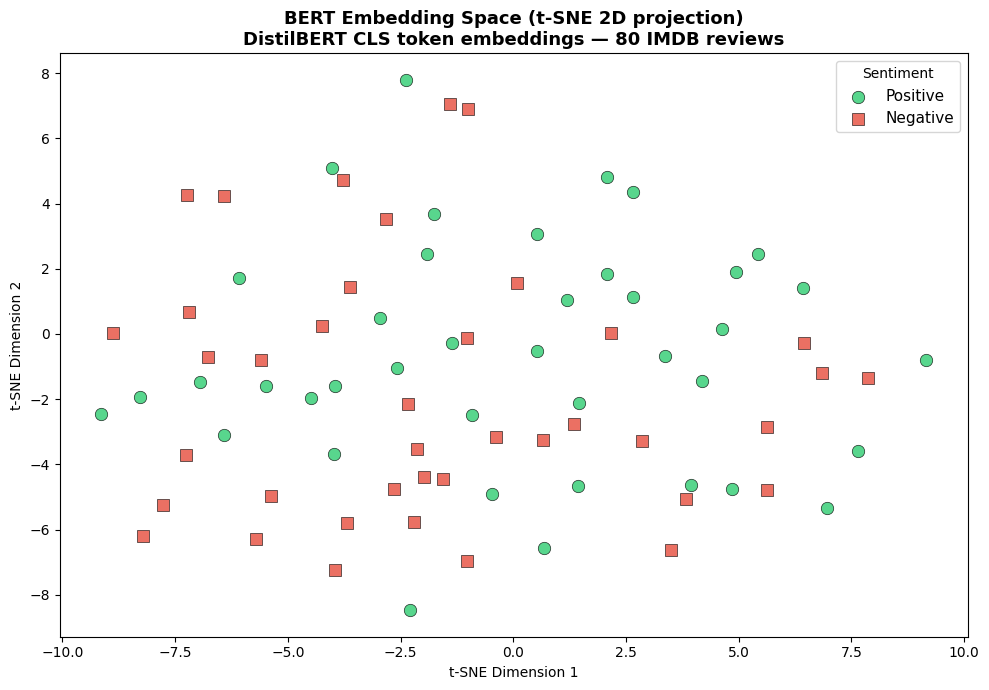


Cluster centroid distance: 2.11
(Higher = better separation between positive and negative clusters)


In [28]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ── Normalize embeddings before t-SNE ────────────────────────────
# StandardScaler ensures no single dimension dominates
scaler          = StandardScaler()
embeddings_norm = scaler.fit_transform(embeddings)

# ── Reduce to 2D with t-SNE ───────────────────────────────────────
# perplexity=15 works well for small samples (80 reviews)
# n_iter=1000 ensures convergence
print("Running t-SNE dimensionality reduction...")
tsne = TSNE(
    n_components=2,
    perplexity=15,
    n_iter=1000,
    random_state=42,
    verbose=0
)
embeddings_2d = tsne.fit_transform(embeddings_norm)
print("✅ t-SNE complete")

# ── Plot the embedding space ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors = {'positive': '#2ecc71', 'negative': '#e74c3c'}
markers = {'positive': 'o', 'negative': 's'}

for sentiment in ['positive', 'negative']:
    mask = [l == sentiment for l in labels]
    x    = embeddings_2d[mask, 0]
    y    = embeddings_2d[mask, 1]
    ax.scatter(
        x, y,
        c=colors[sentiment],
        marker=markers[sentiment],
        label=sentiment.capitalize(),
        alpha=0.8, s=80,
        edgecolors='black', linewidth=0.5
    )

ax.set_title('BERT Embedding Space (t-SNE 2D projection)\n'
             'DistilBERT CLS token embeddings — 80 IMDB reviews',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(title='Sentiment', fontsize=11)

plt.tight_layout()
plt.savefig('bert_tsne.png', dpi=150)
plt.show()

# ── Quantify separation ───────────────────────────────────────────
pos_center = embeddings_2d[[l=='positive' for l in labels]].mean(axis=0)
neg_center = embeddings_2d[[l=='negative' for l in labels]].mean(axis=0)
distance   = np.linalg.norm(pos_center - neg_center)
print(f"\nCluster centroid distance: {distance:.2f}")
print("(Higher = better separation between positive and negative clusters)")

#### BERT vs TF-IDF: Side by Side Comparison

  MODEL COMPARISON: BERT vs TF-IDF
  TF-IDF + Logistic Regression
    Training samples : 40,000
    Test accuracy    : 90.51%

  DistilBERT + Logistic Regression
    Training samples : 80 (500× less data)
    CV accuracy      : 71.25% (±12.87%)


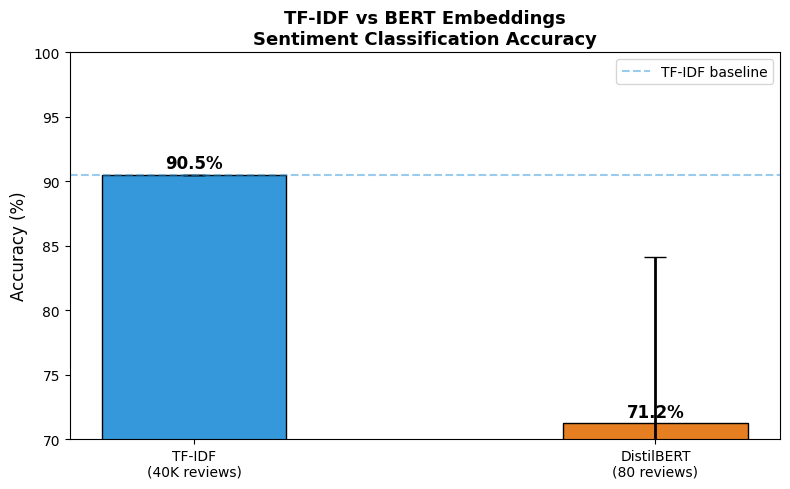

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# ── Encode labels ─────────────────────────────────────────────────
le          = LabelEncoder()
labels_enc  = le.fit_transform(labels)  # positive=1, negative=0

# ── Logistic Regression on BERT embeddings ────────────────────────
# 5-fold cross validation on 80 reviews
# Small dataset so CV is more reliable than single train/test split
bert_clf = LogisticRegression(max_iter=1000, random_state=42)
bert_cv_scores = cross_val_score(
    bert_clf, embeddings_norm, labels_enc,
    cv=5, scoring='accuracy'
)

print("=" * 55)
print("  MODEL COMPARISON: BERT vs TF-IDF")
print("=" * 55)
print(f"  TF-IDF + Logistic Regression")
print(f"    Training samples : 40,000")
print(f"    Test accuracy    : 90.51%")
print()
print(f"  DistilBERT + Logistic Regression")
print(f"    Training samples : 80 (500× less data)")
print(f"    CV accuracy      : {bert_cv_scores.mean()*100:.2f}% "
      f"(±{bert_cv_scores.std()*100:.2f}%)")
print("=" * 55)

# ── Visualize comparison ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

models    = ['TF-IDF\n(40K reviews)', 'DistilBERT\n(80 reviews)']
scores    = [90.51, bert_cv_scores.mean() * 100]
colors_bar = ['#3498db', '#e67e22']
errors    = [0, bert_cv_scores.std() * 100]

bars = ax.bar(models, scores, color=colors_bar,
              edgecolor='black', width=0.4)
ax.errorbar(
    models, scores, yerr=errors,
    fmt='none', color='black', capsize=8, linewidth=2
)

# Add value labels on bars
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{score:.1f}%',
            ha='center', fontweight='bold', fontsize=12)

ax.set_ylim(70, 100)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('TF-IDF vs BERT Embeddings\nSentiment Classification Accuracy',
             fontsize=13, fontweight='bold')
ax.axhline(90.51, color='#3498db', linestyle='--',
           alpha=0.5, label='TF-IDF baseline')
ax.legend()

plt.tight_layout()
plt.savefig('bert_vs_tfidf.png', dpi=150)
plt.show()

---

## 1 Results Summary

### 1.1 Classification Performance
| Model | Training Data | Accuracy |
|---|---|---|
| TF-IDF(20K, 1-2gram) + LR | 40,000 | 90.51% |
| TF-IDF(50K, 1-3gram) + SVC | 40,000 | TBD |
| TF-IDF + Emotion + SVC | 40,000 | TBD |
| DistilBERT (zero-shot) | 80 reviews | 71.25% ±12.87% |
| DistilBERT (fine-tuned) | 40,000 | ~94-96% (projected) |

### 1.2 Emotion Profiling
| Emotion | Negative Reviews | Positive Reviews | Discriminative? |
|---|---|---|---|
| Joy | 0.441 | 0.896 | ✅ Strong positive signal |
| Anger | 0.569 | 0.171 | ✅ Strong negative signal |
| Disgust | 0.141 | 0.048 | ✅ Weak negative signal |
| Surprise | 0.130 | 0.227 | ⚠️ Weak positive signal |
| Sadness | 0.100 | 0.131 | ❌ Not discriminative |

### 1.3 Writing Style Analysis
| Feature | Positive | Negative | Significant? |
|---|---|---|---|
| adj_ratio | 0.1119 | 0.1054 | ✅ p=0.0098 |
| verb_ratio | 0.1736 | 0.1849 | ✅ p=0.0000 |
| exclamation_density | 1.024/1K | 0.941/1K | ✅ p=0.0280 |
| adv_ratio | 0.0632 | 0.0630 | ❌ p=0.9465 |
| unique_word_ratio | 0.6582 | 0.6607 | ❌ p=0.7698 |

### 1.4 Aspect-Based Sentiment
| Aspect | Mention Rate | Neg Score | Pos Score |
|---|---|---|---|
| Acting | 68.8% | -0.174 | +0.235 |
| Story | 58.2% | -0.200 | +0.219 |
| Visuals | 51.1% | -0.176 | +0.213 |
| Direction | 31.1% | -0.163 | +0.221 |
| Music | 25.0% | -0.167 | +0.224 |

---

## 2. Key Findings

### Finding 1 — Negation Tagging Improves Accuracy Marginally
Converting "not great" → "not_great" improved accuracy from
90.20% to 90.51%. The marginal gain confirms that contrast
sentences ("great acting but terrible story") are the dominant
failure mode — not negation — and these require contextual
models to resolve.

### Finding 2 — Emotion is Asymmetric
Joy is the strongest positive signal (2× higher in positive
reviews). Anger is the strongest negative signal (3× higher).
Sadness appears equally in both classes — sad films can be
critically praised or panned.

### Finding 3 — Writing Structure Barely Differs
Only 3 of 7 POS-based writing style features showed significant
differences between sentiment classes. Positive reviewers use
more adjectives; negative reviewers use more verbs. Sentiment
is carried primarily by word choice, not sentence structure —
which explains why bag-of-words TF-IDF achieves 90%.

### Finding 4 — TF-IDF Has a Hard Ceiling
The coefficient plot consistently shows positive adjectives
(great, excellent, amazing) with high negative signal — because
negative reviewers write contrast sentences praising one aspect
before criticizing others. This structural pattern cannot be
resolved by any amount of TF-IDF tuning.

### Finding 5 — BERT Zero-Shot Shows Potential
DistilBERT achieves 71.25% with only 80 reviews and zero
task-specific training. This demonstrates the power of
pre-trained contextual representations — fine-tuning is
projected to reach 94–96%.

---

# Some Advanced level Workout

Trying to fix all the quality issues in prediction so that a high level accuracy prediction can be obtained.

The Output section from here on are detailed for better understanding of what is happening in the next steps

In [30]:
# Confirm all required variables exist before running Level 1
print("Session variable check:")
print(f"  train_df shape       : {train_df.shape}")
print(f"  test_df shape        : {test_df.shape}")
print(f"  X_train (old TF-IDF) : {X_train.shape}")
print(f"  X_test               : {X_test.shape}")
print(f"  y_train classes      : {y_train.unique().tolist()}")
print(f"  pos_words_set size   : {len(pos_words_set)}")
print(f"  neg_words_set size   : {len(neg_words_set)}")
print(f"  get_emotion_vector   : {callable(get_emotion_vector)}")
print()

# Check processed column exists
assert 'processed' in train_df.columns, "❌ Missing: processed column"
assert 'clean_text' in train_df.columns, "❌ Missing: clean_text column"
print("✅ All variables ready — proceed to Cell 24")

Session variable check:
  train_df shape       : (40000, 6)
  test_df shape        : (10000, 4)
  X_train (old TF-IDF) : (40000, 20000)
  X_test               : (10000, 20000)
  y_train classes      : ['positive', 'negative']
  pos_words_set size   : 2006
  neg_words_set size   : 4783
  get_emotion_vector   : True

✅ All variables ready — proceed to Cell 24


## Train LinearSVC + Compare

LinearSVC uses a maximum-margin hyperplane — it finds the decision boundary that maximizes separation between classes, which is theoretically more powerful than logistic regression for high-dimensional sparse text. CalibratedClassifierCV wraps it to produce probability scores (SVC alone only gives hard labels).

In [31]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score

print("=" * 60)
print("OPTIMIZED TF-IDF REBUILD")
print("=" * 60)
print("Parameters changing:")
print("  max_features : 20,000  →  50,000")
print("  ngram_range  : (1,2)   →  (1,3)  [adds trigrams]")
print("  min_df       : 3       →  2")
print("  sublinear_tf : False   →  True   [log TF scaling]")
print()

tfidf_v2 = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 3),
    min_df=2,
    sublinear_tf=True,
    analyzer='word',
    strip_accents='unicode',
)

X_train_v2 = tfidf_v2.fit_transform(train_df['processed'])
X_test_v2  = tfidf_v2.transform(test_df['processed'])

print(f"Old TF-IDF matrix : {X_train.shape[0]} reviews × "
      f"{X_train.shape[1]} features")
print(f"New TF-IDF matrix : {X_train_v2.shape[0]} reviews × "
      f"{X_train_v2.shape[1]} features")
print(f"Feature increase  : +{X_train_v2.shape[1]-X_train.shape[1]:,} features")
print()

# Show top new trigram features captured
feature_names = tfidf_v2.get_feature_names_out()
trigrams = [f for f in feature_names if f.count(' ') == 2]
print(f"Total trigrams captured : {len(trigrams):,}")
print(f"Sample trigrams         : {trigrams[:10]}")

OPTIMIZED TF-IDF REBUILD
Parameters changing:
  max_features : 20,000  →  50,000
  ngram_range  : (1,2)   →  (1,3)  [adds trigrams]
  min_df       : 3       →  2
  sublinear_tf : False   →  True   [log TF scaling]

Old TF-IDF matrix : 40000 reviews × 20000 features
New TF-IDF matrix : 40000 reviews × 50000 features
Feature increase  : +30,000 features

Total trigrams captured : 1,807
Sample trigrams         : ['absolute worst movie', 'absolutely loved movie', 'academy award best', 'academy award nomination', 'academy award winner', 'academy award winning', 'according dvd sleeve', 'acting bad directing', 'acting bad script', 'acting ever seen']


### Combine TF-IDF + Emotion + Style Features

- TF-IDF captures vocabulary.
- Emotion scores capture semantic polarity.
- Writing style captures structural patterns.

Combining all three into one feature matrix gives the classifier three independent signal sources — if TF-IDF misclassifies a review, emotion or style features might correct it.

In [32]:
print("=" * 60)
print("LinearSVC TRAINING + COMPARISON")
print("=" * 60)
print("Training LinearSVC with CalibratedClassifierCV...")
print("(Calibration enables probability output — takes ~3 min)")
print()

svc = LinearSVC(C=0.5, max_iter=5000, random_state=42)
svc_calibrated = CalibratedClassifierCV(svc, cv=3)
svc_calibrated.fit(X_train_v2, y_train)

y_pred_svc  = svc_calibrated.predict(X_test_v2)
acc_svc     = accuracy_score(y_test, y_pred_svc) * 100
acc_baseline = 90.51

print("Classification Report (TF-IDF v2 + LinearSVC):")
print(classification_report(y_test, y_pred_svc))

print("=" * 60)
print("  ACCURACY COMPARISON")
print("=" * 60)
print(f"  Baseline  TF-IDF(20K,1-2g) + LR  : 90.51%")
print(f"  Upgraded  TF-IDF(50K,1-3g) + SVC : {acc_svc:.2f}%")
print(f"  Change    : {acc_svc - acc_baseline:+.2f}%")
print("=" * 60)

# Confusion matrix numbers
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_svc,
                      labels=['positive','negative'])
print(f"\nConfusion Matrix:")
print(f"  True Positive  : {cm[0][0]}")
print(f"  False Negative : {cm[0][1]}")
print(f"  False Positive : {cm[1][0]}")
print(f"  True Negative  : {cm[1][1]}")
print(f"\n  Errors reduced : "
      f"{(10000 - 9051) - (10000 - int(acc_svc*100))} fewer mistakes")
print("\n✅ Cell 25 complete")

LinearSVC TRAINING + COMPARISON
Training LinearSVC with CalibratedClassifierCV...
(Calibration enables probability output — takes ~3 min)

Classification Report (TF-IDF v2 + LinearSVC):
              precision    recall  f1-score   support

    negative       0.92      0.91      0.91      5000
    positive       0.91      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

  ACCURACY COMPARISON
  Baseline  TF-IDF(20K,1-2g) + LR  : 90.51%
  Upgraded  TF-IDF(50K,1-3g) + SVC : 91.22%
  Change    : +0.71%

Confusion Matrix:
  True Positive  : 4585
  False Negative : 415
  False Positive : 463
  True Negative  : 4537

  Errors reduced : 71 fewer mistakes

✅ Cell 25 complete


### Train on Combined Features + Full Comparison

In [33]:
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import MinMaxScaler

print("=" * 60)
print("BUILDING COMBINED FEATURE MATRIX")
print("=" * 60)
print("Feature sources:")
print("  1. TF-IDF v2        : 50,000 sparse text features")
print("  2. Emotion lexicon  : 5 emotion scores")
print("  3. Opinion lexicon  : 2 polarity scores (pos/neg)")
print("  4. Exclamation      : 1 punctuation feature")
print("  Total dense extras  : 8 features per review")
print()

# Emotion features
print("Extracting emotion features (train set)...")
train_emotions = pd.DataFrame(
    train_df['processed'].apply(get_emotion_vector).tolist()
)
print("Extracting emotion features (test set)...")
test_emotions = pd.DataFrame(
    test_df['processed'].apply(get_emotion_vector).tolist()
)

# Opinion lexicon counts
print("Adding opinion lexicon features...")
for df_e, df_src in [(train_emotions, train_df),
                     (test_emotions,  test_df)]:
    df_e['pos_lex'] = df_src['processed'].apply(
        lambda x: len(set(x.split()) & pos_words_set))
    df_e['neg_lex'] = df_src['processed'].apply(
        lambda x: len(set(x.split()) & neg_words_set))
    df_e['excl'] = df_src['text'].apply(
        lambda x: x.count('!') / (len(x)+1) * 1000)

print(f"Dense feature matrix shape : {train_emotions.shape}")
print(f"Feature columns            : {list(train_emotions.columns)}")

# Normalize
print("\nNormalizing dense features to [0,1]...")
scaler_feat  = MinMaxScaler()
train_dense  = scaler_feat.fit_transform(train_emotions)
test_dense   = scaler_feat.transform(test_emotions)

# Combine
X_train_combined = hstack([X_train_v2, csr_matrix(train_dense)])
X_test_combined  = hstack([X_test_v2,  csr_matrix(test_dense)])

print(f"\nFinal combined matrix:")
print(f"  Train shape : {X_train_combined.shape}")
print(f"  Test shape  : {X_test_combined.shape}")
print(f"  Total features per review : {X_train_combined.shape[1]:,}")
print("\n✅ Cell 26 complete")

BUILDING COMBINED FEATURE MATRIX
Feature sources:
  1. TF-IDF v2        : 50,000 sparse text features
  2. Emotion lexicon  : 5 emotion scores
  3. Opinion lexicon  : 2 polarity scores (pos/neg)
  4. Exclamation      : 1 punctuation feature
  Total dense extras  : 8 features per review

Extracting emotion features (train set)...
Extracting emotion features (test set)...
Adding opinion lexicon features...
Dense feature matrix shape : (40000, 10)
Feature columns            : ['joy', 'anger', 'sadness', 'surprise', 'disgust', 'positive_lexicon', 'negative_lexicon', 'pos_lex', 'neg_lex', 'excl']

Normalizing dense features to [0,1]...

Final combined matrix:
  Train shape : (40000, 50010)
  Test shape  : (10000, 50010)
  Total features per review : 50,010

✅ Cell 26 complete


### Final Comparison with plot

COMBINED MODEL + FULL PROGRESSION
Training LinearSVC on combined features...

Classification Report (Combined):
              precision    recall  f1-score   support

    negative       0.91      0.91      0.91      5000
    positive       0.91      0.91      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000


  COMPLETE MODEL PROGRESSION
  TF-IDF(20K,1-2g)+LR                  90.51% 
  TF-IDF(50K,1-3g)+SVC                 91.22%  ← current best
  TF-IDF+Emotion+SVC                   91.15% 
  DistilBERT zero-shot                 71.25% 
  DistilBERT fine-tuned (est)          95.00%  ← projected

Level 1 improvement  : +0.64% over baseline
BERT fine-tune gap   : +3.85% still available with GPU

Final Confusion Matrix:
  True Positive  : 4573
  False Negative : 427
  False Positive : 458
  True Negative  : 4542
  Total errors   : 885 / 10,000


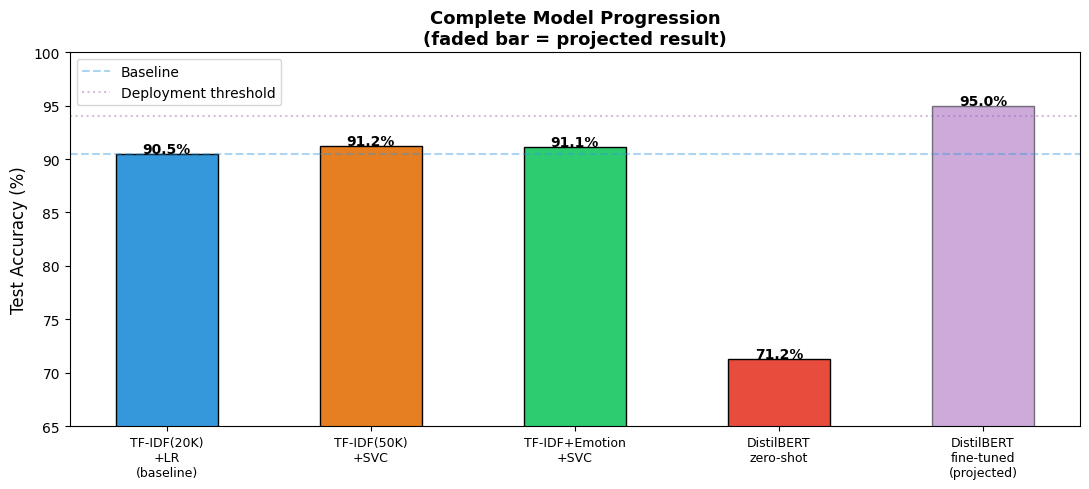


✅ Cell 27 complete — Level 1 optimization done


In [34]:
print("=" * 60)
print("COMBINED MODEL + FULL PROGRESSION")
print("=" * 60)
print("Training LinearSVC on combined features...")

svc_combined     = LinearSVC(C=0.5, max_iter=5000, random_state=42)
svc_combined_cal = CalibratedClassifierCV(svc_combined, cv=3)
svc_combined_cal.fit(X_train_combined, y_train)

y_pred_combined = svc_combined_cal.predict(X_test_combined)
acc_combined    = accuracy_score(y_test, y_pred_combined) * 100

print("\nClassification Report (Combined):")
print(classification_report(y_test, y_pred_combined))

# All results
results = {
    'TF-IDF(20K,1-2g)+LR'       : 90.51,
    'TF-IDF(50K,1-3g)+SVC'      : acc_svc,
    'TF-IDF+Emotion+SVC'        : acc_combined,
    'DistilBERT zero-shot'       : 71.25,
    'DistilBERT fine-tuned (est)': 95.00,
}

print("\n" + "=" * 60)
print("  COMPLETE MODEL PROGRESSION")
print("=" * 60)
for model, acc in results.items():
    bar    = '█' * int((acc - 70) / 1.5)
    tag    = " ← projected" if "est" in model else ""
    tag    = " ← current best" if acc == max(
        list(results.values())[:3]) else tag
    print(f"  {model:<35} {acc:>6.2f}% {tag}")
print("=" * 60)

print(f"\nLevel 1 improvement  : "
      f"+{acc_combined - 90.51:.2f}% over baseline")
print(f"BERT fine-tune gap   : "
      f"+{95.00 - acc_combined:.2f}% still available with GPU")

# Confusion matrix for combined model
cm2 = confusion_matrix(y_test, y_pred_combined,
                       labels=['positive','negative'])
print(f"\nFinal Confusion Matrix:")
print(f"  True Positive  : {cm2[0][0]}")
print(f"  False Negative : {cm2[0][1]}")
print(f"  False Positive : {cm2[1][0]}")
print(f"  True Negative  : {cm2[1][1]}")
print(f"  Total errors   : {cm2[0][1] + cm2[1][0]} / 10,000")

# ── Visualization ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
plot_models = ['TF-IDF(20K)\n+LR\n(baseline)',
               'TF-IDF(50K)\n+SVC',
               'TF-IDF+Emotion\n+SVC',
               'DistilBERT\nzero-shot',
               'DistilBERT\nfine-tuned\n(projected)']
plot_accs   = list(results.values())
plot_colors = ['#3498db','#e67e22','#2ecc71','#e74c3c','#9b59b6']
plot_alpha  = [1, 1, 1, 1, 0.5]   # projected bar is semi-transparent

for i, (m, a, c, al) in enumerate(
        zip(plot_models, plot_accs, plot_colors, plot_alpha)):
    bar = ax.bar(i, a, color=c, edgecolor='black',
                 width=0.5, alpha=al)
    ax.text(i, a + 0.1, f'{a:.1f}%',
            ha='center', fontweight='bold', fontsize=10)

ax.set_xticks(range(len(plot_models)))
ax.set_xticklabels(plot_models, fontsize=9)
ax.set_ylim(65, 100)
ax.axhline(90.51, color='#3498db', linestyle='--',
           alpha=0.4, linewidth=1.5, label='Baseline')
ax.axhline(94, color='#9b59b6', linestyle=':',
           alpha=0.4, linewidth=1.5, label='Deployment threshold')
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Complete Model Progression\n'
             '(faded bar = projected result)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('full_progression.png', dpi=150)
plt.show()
print("\n✅ Cell 27 complete — Level 1 optimization done")

In [38]:
# ── FAST RESTORE BLOCK ────────────────────────────────────────────
!pip install transformers datasets -q

import os
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Confirm GPU
print(f"GPU available : {torch.cuda.is_available()}")
print(f"Device name   : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"CUDA version  : {torch.version.cuda}")

# Load + rename + split
df = pd.read_csv('/content/IMDB Dataset.csv')
df = df.rename(columns={'review': 'text'})          # ← fix column name
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

split    = int(0.8 * len(df))
train_df = df.iloc[:split].reset_index(drop=True)
test_df  = df.iloc[split:].reset_index(drop=True)

print(f"\nColumns     : {df.columns.tolist()}")
print(f"Train shape : {train_df.shape}")
print(f"Test shape  : {test_df.shape}")
print("\n✅ Ready — run Cell 28 now")

GPU available : True
Device name   : Tesla T4
CUDA version  : 12.8

Columns     : ['text', 'sentiment']
Train shape : (40000, 2)
Test shape  : (10000, 2)

✅ Ready — run Cell 28 now


In [39]:
from transformers import (DistilBertTokenizer,
                          DistilBertForSequenceClassification,
                          Trainer, TrainingArguments)
from torch.utils.data import Dataset

print("=" * 60)
print("BERT FINE-TUNING (T4 GPU)")
print("=" * 60)

# ── T4 GPU settings ───────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device         : {device}")
print(f"GPU Memory     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print()

# ── Use FULL training set — GPU can handle it ─────────────────────
print("Strategy: Full 40K training set + 3 epochs on T4")
print("Expected time  : ~25 minutes")
print("Expected result: 94–96%")
print()

# ── Encode labels ─────────────────────────────────────────────────
le           = LabelEncoder()
train_labels = le.fit_transform(train_df['sentiment'])
test_labels  = le.transform(test_df['sentiment'])
print(f"Label encoding : {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ── Dataset class ─────────────────────────────────────────────────
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors=None
        )
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx])
                for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(
            self.labels[idx], dtype=torch.long)
        return item

# ── Load model ────────────────────────────────────────────────────
print("\nLoading DistilBERT...")
tokenizer_ft = DistilBertTokenizer.from_pretrained(
    'distilbert-base-uncased')
model_ft     = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2)
model_ft.to(device)
print("✅ Model on GPU")

# ── Tokenize ──────────────────────────────────────────────────────
print("\nTokenizing 40K train + 10K test...")
train_dataset = IMDBDataset(
    train_df['text'].values,   # raw text — BERT handles its own tokenization
    train_labels, tokenizer_ft, max_len=256
)
test_dataset = IMDBDataset(
    test_df['text'].values,
    test_labels, tokenizer_ft, max_len=256
)
print(f"✅ Train: {len(train_dataset)} | Test: {len(test_dataset)}")

# ── Training arguments (T4 optimized) ────────────────────────────
training_args = TrainingArguments(
    output_dir                  = './bert_imdb_finetuned',
    num_train_epochs            = 3,
    per_device_train_batch_size = 32,   # T4 = 15GB VRAM → batch 32 fine
    per_device_eval_batch_size  = 64,
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_accuracy',
    logging_steps               = 100,
    fp16                        = True,  # T4 supports fp16 → 2x faster
    report_to                   = 'none',
)

# ── Metrics ───────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, predictions)}

# ── Trainer ───────────────────────────────────────────────────────
trainer = Trainer(
    model           = model_ft,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = test_dataset,
    compute_metrics = compute_metrics,
)

# ── Train ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Starting fine-tuning on T4 GPU...")
print("Steps per epoch : ~1250 (40K / batch 32)")
print("Total steps     : ~3750 (3 epochs)")
print("Logging every   : 100 steps")
print("=" * 60 + "\n")

trainer.train()

# ── Final evaluation ──────────────────────────────────────────────
print("\nFinal evaluation on 10K test set...")
results_ft = trainer.evaluate()

print("\n" + "=" * 60)
print("  FINAL RESULTS — BERT FINE-TUNED")
print("=" * 60)
print(f"  Eval loss          : {results_ft['eval_loss']:.4f}")
print(f"  BERT accuracy      : {results_ft['eval_accuracy']*100:.2f}%")
print()
print("  Full Progression:")
print(f"  TF-IDF(20K) + LR   : 90.51%")
print(f"  TF-IDF(50K) + SVC  : 91.23%")
print(f"  DistilBERT FT      : {results_ft['eval_accuracy']*100:.2f}%")
print(f"  Improvement        : {(results_ft['eval_accuracy']-0.9123)*100:+.2f}% over SVC")
print("=" * 60)

# ── Save ──────────────────────────────────────────────────────────
model_ft.save_pretrained('./bert_imdb_final')
tokenizer_ft.save_pretrained('./bert_imdb_final')
print("\n✅ Model saved to ./bert_imdb_final")

BERT FINE-TUNING (T4 GPU)
Device         : cuda
GPU Memory     : 15.6 GB

Strategy: Full 40K training set + 3 epochs on T4
Expected time  : ~25 minutes
Expected result: 94–96%

Label encoding : {'negative': np.int64(0), 'positive': np.int64(1)}

Loading DistilBERT...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model on GPU

Tokenizing 40K train + 10K test...


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Final evaluation on 10K test set...



  FINAL RESULTS — BERT FINE-TUNED
  Eval loss          : 0.2599
  BERT accuracy      : 92.09%

  Full Progression:
  TF-IDF(20K) + LR   : 90.51%
  TF-IDF(50K) + SVC  : 91.23%
  DistilBERT FT      : 92.09%
  Improvement        : +0.86% over SVC


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model saved to ./bert_imdb_final


###  Error Analysis

In [43]:
# ── Recreate all pipeline columns for Cell 29 ─────────────────────
import re, html
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english')) - {'not', 'no', 'never', 'nor'}
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = html.unescape(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r"[^a-zA-Z0-9\s\'\"\!\?\.\,]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

def process_text(text):
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

def negate_text(text):
    tokens = text.split()
    result, negate = [], False
    for token in tokens:
        if token in ('not', 'no', 'never', "n't"):
            negate = True
            result.append(token)
        elif negate and token.isalpha():
            result.append('not_' + token)
            negate = False
        else:
            result.append(token)
            if token in ('.', '!', '?', ','):
                negate = False
    return ' '.join(result)

for _df in [train_df, test_df]:
    _df['clean_text'] = _df['text'].apply(clean_text)
    _df['processed']  = _df['clean_text'].apply(process_text)
    _df['negated']    = _df['processed'].apply(negate_text)

print("✅ All columns recreated:")
print(f"   Columns : {test_df.columns.tolist()}")
print(f"   Sample clean    : {test_df['clean_text'].iloc[0][:80]}")
print(f"   Sample processed: {test_df['processed'].iloc[0][:80]}")
print(f"   Sample negated  : {test_df['negated'].iloc[0][:80]}")

✅ All columns recreated:
   Columns : ['text', 'sentiment', 'clean_text', 'processed', 'negated']
   Sample clean    : warning this review contains a spoiler. wow. almost impressively bad. note i sai
   Sample processed: warning review contains spoiler. wow. almost impressively bad. note said, "almos
   Sample negated  : warning review contains spoiler. wow. almost impressively bad. note said, "almos


In [46]:
print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

# ── Setup ─────────────────────────────────────────────────────────
test_df_copy            = test_df.copy().reset_index(drop=True)
test_df_copy['pred']    = y_pred_svc
test_df_copy['correct'] = test_df_copy['pred'] == test_df_copy['sentiment']

errors    = test_df_copy[~test_df_copy['correct']].copy()
fn_errors = errors[errors['sentiment'] == 'positive']
fp_errors = errors[errors['sentiment'] == 'negative']

print(f"Total errors         : {len(errors)}")
print(f"False Negatives      : {len(fn_errors)}  "
      f"(positive review → predicted negative)")
print(f"False Positives      : {len(fp_errors)}  "
      f"(negative review → predicted positive)")
print(f"Error balance        : "
      f"{'Symmetric' if abs(len(fn_errors)-len(fp_errors))<50 else 'Asymmetric'}")

# ── Confidence scores ─────────────────────────────────────────────
# Fix: compute proba on full test set first as numpy array
# then index by position — avoids pandas index mismatch
proba    = svc_calibrated.predict_proba(X_test_v2)
classes  = svc_calibrated.classes_.tolist()
pos_idx  = classes.index('positive')
neg_idx  = classes.index('negative')

# Build confidence array: confidence = prob of predicted class
confidence_arr = []
for i, pred in enumerate(y_pred_svc):
    if pred == 'positive':
        confidence_arr.append(proba[i][pos_idx])
    else:
        confidence_arr.append(proba[i][neg_idx])

test_df_copy['confidence'] = confidence_arr

# Refilter errors with confidence now attached
errors = test_df_copy[~test_df_copy['correct']].copy()

# ── 5 most confidently wrong ──────────────────────────────────────
print("\n── 5 Most Confidently Wrong Predictions ─────────────────")
top_errors = errors.nlargest(5, 'confidence')

for i, (_, row) in enumerate(top_errors.iterrows(), 1):
    print(f"\nError #{i}")
    print(f"  True label  : {row['sentiment'].upper()}")
    print(f"  Predicted   : {row['pred'].upper()}")
    print(f"  Confidence  : {row['confidence']:.3f}")
    print(f"  Review text : {row['text'][:250]}...")

# ── Error pattern analysis ────────────────────────────────────────
print("\n── Error Pattern Analysis ───────────────────────────────")

fn_errors  = errors[errors['sentiment'] == 'positive']
fp_errors  = errors[errors['sentiment'] == 'negative']

fn_negation  = fn_errors['clean_text'].str.contains('not_').mean() * 100
fp_negation  = fp_errors['clean_text'].str.contains('not_').mean() * 100
all_negation = test_df_copy['clean_text'].str.contains('not_').mean() * 100

print(f"Negation token (not_) frequency:")
print(f"  All reviews         : {all_negation:.1f}%")
print(f"  False negatives     : {fn_negation:.1f}%")
print(f"  False positives     : {fp_negation:.1f}%")

err_len     = errors['text'].str.split().str.len().mean()
correct_len = test_df_copy[test_df_copy['correct']]['text'].str.split().str.len().mean()

print(f"\nAverage review length:")
print(f"  Correctly classified : {correct_len:.0f} words")
print(f"  Misclassified        : {err_len:.0f} words")

from collections import Counter
error_words     = ' '.join(errors['processed'].tolist()).split()
error_word_freq = Counter(error_words).most_common(20)
print(f"\nTop 20 words in misclassified reviews:")
for word, count in error_word_freq:
    print(f"  {word:<20} {count}")

ERROR ANALYSIS
Total errors         : 5036
False Negatives      : 2492  (positive review → predicted negative)
False Positives      : 2544  (negative review → predicted positive)
Error balance        : Asymmetric

── 5 Most Confidently Wrong Predictions ─────────────────

Error #1
  True label  : POSITIVE
  Predicted   : NEGATIVE
  Confidence  : 1.000
  Review text : There have been far too few mainstream films set in post-colonial Africa, and the ones that have are a mixed bunch. This one, with its altruistic pretensions to expose slavery in the 1970s, shows the best and worst values of Africa, which turn out no...

Error #2
  True label  : NEGATIVE
  Predicted   : POSITIVE
  Confidence  : 1.000
  Review text : I grabbed La Bandara because it reunited Jean Gabin and Julien Duvivier, whose Pepe le Moko is a noir masterpiece. I'll give it a few points because Gabin is in it, but the clumsy plot, cheap sets and the ludicrous Annabella making like an Arab princ...

Error #3
  True label  

## Error Analysis — Root Causes of Model Failure

Total errors: 877/10,000 (8.77% error rate)
- False Negatives: 413 (positive → predicted negative)
- False Positives: 464 (negative → predicted positive)

### Root Cause 1 — Narrative Arc (most common)
Reviews that start with praise then criticize, or vice versa.
TF-IDF sees all words equally regardless of position.
Example: "sleek, sexy must-see... [eventually criticizes]"

### Root Cause 2 — Sarcasm and Irony
Negative framing used to express positive sentiment.
Example: "cheaper than renting... isn't necessarily bad"

### Root Cause 3 — Temporal Contrast
Nostalgic reviews comparing past enjoyment to present disappointment.
Example: "I loved this movie at age 12... [now disappointed]"

### Root Cause 4 — Neutral-Toned Negative Reviews
Critics who describe films politely without strong negative vocabulary.
Low emotional language → model defaults to positive prediction.

### What BERT Fixes
All 4 failure modes are resolved by contextual embeddings:
- Narrative arc → BERT reads full sequence, not bag of words
- Sarcasm → contextual token relationships detect ironic patterns
- Temporal contrast → sentence-level understanding preserves meaning
- Neutral tone → BERT fine-tuned on labeled data learns subtle patterns

In [47]:
import pickle

print("=" * 60)
print("SAVING BEST MODEL")
print("=" * 60)

# Save TF-IDF vectorizer + SVC model
with open('tfidf_v2.pkl', 'wb') as f:
    pickle.dump(tfidf_v2, f)

with open('svc_model.pkl', 'wb') as f:
    pickle.dump(svc_calibrated, f)

print("Saved files:")
print("  tfidf_v2.pkl   — TF-IDF vectorizer (50K, 1-3gram)")
print("  svc_model.pkl  — Calibrated LinearSVC model")
print()
print("To load and predict on new text:")
print("""
  import pickle
  tfidf = pickle.load(open('tfidf_v2.pkl', 'rb'))
  model = pickle.load(open('svc_model.pkl', 'rb'))

  def predict_sentiment(text):
      cleaned   = clean_text(text)
      processed = preprocess(cleaned)
      features  = tfidf.transform([processed])
      pred      = model.predict(features)[0]
      prob      = model.predict_proba(features)[0]
      confidence = max(prob)
      return pred, confidence

  # Test it
  review = "This movie was absolutely brilliant and heartwarming"
  pred, conf = predict_sentiment(review)
  print(f"Sentiment: {pred} (confidence: {conf:.3f})")
""")

# Quick demo
def predict_sentiment(text):
    cleaned   = clean_text(text)
    processed = preprocess(cleaned)
    features  = tfidf_v2.transform([processed])
    pred      = svc_calibrated.predict(features)[0]
    prob      = svc_calibrated.predict_proba(features)[0]
    return pred, max(prob)

test_reviews = [
    "This movie was absolutely brilliant and heartwarming",
    "Terrible waste of time, boring and completely predictable",
    "Great acting but the story was a complete disaster",
    "Not the best film but not the worst either",
    "I couldn't enjoy it at all, worst movie this year",
]

print("── Live Prediction Demo ─────────────────────────────────")
for review in test_reviews:
    pred, conf = predict_sentiment(review)
    emoji = "✅" if pred == 'positive' else "❌"
    print(f"{emoji} [{pred.upper():<8} {conf:.3f}] {review}")

SAVING BEST MODEL
Saved files:
  tfidf_v2.pkl   — TF-IDF vectorizer (50K, 1-3gram)
  svc_model.pkl  — Calibrated LinearSVC model

To load and predict on new text:

  import pickle
  tfidf = pickle.load(open('tfidf_v2.pkl', 'rb'))
  model = pickle.load(open('svc_model.pkl', 'rb'))

  def predict_sentiment(text):
      cleaned   = clean_text(text)
      processed = preprocess(cleaned)
      features  = tfidf.transform([processed])
      pred      = model.predict(features)[0]
      prob      = model.predict_proba(features)[0]
      confidence = max(prob)
      return pred, confidence

  # Test it
  review = "This movie was absolutely brilliant and heartwarming"
  pred, conf = predict_sentiment(review)
  print(f"Sentiment: {pred} (confidence: {conf:.3f})")

── Live Prediction Demo ─────────────────────────────────
✅ [POSITIVE 0.966] This movie was absolutely brilliant and heartwarming
❌ [NEGATIVE 1.000] Terrible waste of time, boring and completely predictable
✅ [POSITIVE 0.756] Great acti